<a href="https://colab.research.google.com/github/eduardo-illueca/icg-project/blob/main/Detection/HC_Model_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook applies the Characteristic Point Detector (model_v19.keras), trained on the ReBeat database, to the HeartCycle database. We evaluate the detector's robustness against signal variations and changes in hemodynamic parameters. Signal processing steps are preserved to maintain access to the variables used during training.

# Load Data

In [ ]:
import numpy as np
import pandas as pd
import scipy
import matplotlib
import sklearn
import tensorflow

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Scikit-learn:", sklearn.__version__)
print("TensorFlow:", tensorflow.__version__)


NumPy: 2.0.2
Pandas: 2.2.2
SciPy: 1.15.3
Matplotlib: 3.10.0
Scikit-learn: 1.6.1
TensorFlow: 2.18.0


We load the data from Google Drive.

In [ ]:
import os
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
from google.colab import drive

from scipy.signal import butter, filtfilt, savgol_filter, resample
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler  # Z-score scaler

from tensorflow.keras.models import load_model

In [ ]:
def preprocess_icg_detrend(icg_data, icg_time, fs, lowcut=0.7, highcut=20.0, order=2, sg_window=301, sg_poly=2):
    # Bandpass filter
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    icg_bandpassed = filtfilt(b, a, icg_data)

    # Baseline estimation using SG and subtraction
    baseline = savgol_filter(icg_bandpassed, window_length=sg_window, polyorder=sg_poly)
    icg_detrended = icg_bandpassed - baseline

    return icg_detrended

In [ ]:
def bandpass(signal, fs, lowcut, highcut, order=2):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

In [ ]:
import scipy.io as sio
import numpy as np
import os
from scipy.signal import butter, filtfilt, savgol_filter
from sklearn.preprocessing import StandardScaler
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# --- Preprocessing function ---
def preprocess_signals(icg_data, icg_time, ecg_data, fs_icg=200, fs_ecg=200):
    # Bandpass filter ICG: 0.7–20 Hz
    nyq_icg = 0.5 * fs_icg
    low_icg = 0.7 / nyq_icg
    high_icg = 20.0 / nyq_icg
    b_icg, a_icg = butter(N=2, Wn=[low_icg, high_icg], btype='band')
    icg_bandpassed = filtfilt(b_icg, a_icg, icg_data)

    # Detrend
    baseline = savgol_filter(icg_bandpassed, window_length=301, polyorder=2)
    icg_detrended = icg_bandpassed - baseline

    # Derivative
    dt = np.mean(np.diff(icg_time))
    dz_dt = np.gradient(icg_detrended, dt)

    # Normalize dz/dt
    scaler_icg = StandardScaler()
    dz_dt_norm = scaler_icg.fit_transform(dz_dt.reshape(-1, 1)).flatten()

    # Bandpass filter ECG: 0.5–45 Hz
    nyq_ecg = 0.5 * fs_ecg
    low_ecg = 0.5 / nyq_ecg
    high_ecg = 45.0 / nyq_ecg
    b_ecg, a_ecg = butter(N=2, Wn=[low_ecg, high_ecg], btype='band')
    ecg_bandpassed = filtfilt(b_ecg, a_ecg, ecg_data)

    # Normalize ECG
    scaler_ecg = StandardScaler()
    ecg_norm = scaler_ecg.fit_transform(ecg_bandpassed.reshape(-1, 1)).flatten()

    return dz_dt_norm, ecg_norm

# --- Initialize output ---
all_data = {}

# --- Define folder + file loop structure ---
file_specs = [
    {
        "dir": "/content/drive/MyDrive/TFG/Data_HeartCycle/59146237",
        "prefix": "",
        "range": range(1, 38)
    },
    {
        "dir": "/content/drive/MyDrive/TFG/Data_HeartCycle/59146238",
        "prefix": "",
        "range": [i for i in range(1, 84) if i != 42]
    },
    {
        "dir": "/content/drive/MyDrive/TFG/Data_HeartCycle/59146239",
        "custom_files": (
            [("CH17_", i) for i in range(1, 15)] +
            [("CH16_", i) for i in range(15, 26)] +
            [("CH15_", i) for i in range(38, 43)]
        )
    }
]

# --- Main processing loop ---
for spec in file_specs:
    dir_path = spec["dir"]
    patient_id = dir_path.split("/")[-1]  # Extract '5914623X'

    if "custom_files" in spec:
        file_list = spec["custom_files"]
    else:
        file_list = [(spec["prefix"], i) for i in spec["range"]]

    for prefix, i in file_list:
        filename = f"{prefix}{patient_id}_s00000{i:02d}.mat"
        file_path = os.path.join(dir_path, filename)

        if not os.path.exists(file_path):
            print(f"File not found: {file_path}")
            continue

        print(f"\nProcessing file: {filename}")
        try:
            data_hc = sio.loadmat(file_path)

            if 'measure' not in data_hc:
                print("No 'measure' key found.")
                continue

            measures = data_hc['measure']

            # Extract signals
            icg = measures[1, 1]
            icg_time = icg['time'][0, 0].flatten()
            icg_data = icg['data'][0, 0].flatten()

            ecg = measures[0, 1]
            ecg_time = ecg['time'][0, 0].flatten()
            ecg_data = ecg['data'][0, 0].flatten()

            rpeaks = measures[2, 1]
            rpeaks_times = rpeaks['data'][0, 0].flatten()
            rpeaks_indices = np.array([np.argmin(np.abs(ecg_time - t)) for t in rpeaks_times])

            pep_values = measures[4, 1]['data'][0, 0].flatten()
            lvet_values = measures[6, 1]['data'][0, 0].flatten()

            # AVO and AVC extraction
            avo_times = measures[3, 1]['data'][0, 0].flatten()
            avc_times = measures[5, 1]['data'][0, 0].flatten()

            # Preprocess
            dz_dt_norm, ecg_norm = preprocess_signals(
                icg_data=icg_data,
                icg_time=icg_time,
                ecg_data=ecg_data,
                fs_icg=200,
                fs_ecg=200
            )

            # Store
            all_data[filename] = {
                "dz_dt_norm": dz_dt_norm,
                "ecg_norm": ecg_norm,
                "icg_time": icg_time,
                "ecg_time": ecg_time,
                "rpeaks_time": rpeaks_times,
                "rpeaks_index": rpeaks_indices,
                "pep_ms": pep_values,
                "lvet_ms": lvet_values,
                "avo_time": avo_times,
                "avc_time": avc_times
            }

        except Exception as e:
            print(f"Error processing {filename}: {e}")
            continue


Mounted at /content/drive

Processing file: 59146237_s0000001.mat

Processing file: 59146237_s0000002.mat

Processing file: 59146237_s0000003.mat

Processing file: 59146237_s0000004.mat

Processing file: 59146237_s0000005.mat

Processing file: 59146237_s0000006.mat

Processing file: 59146237_s0000007.mat

Processing file: 59146237_s0000008.mat

Processing file: 59146237_s0000009.mat

Processing file: 59146237_s0000010.mat

Processing file: 59146237_s0000011.mat

Processing file: 59146237_s0000012.mat

Processing file: 59146237_s0000013.mat

Processing file: 59146237_s0000014.mat

Processing file: 59146237_s0000015.mat

Processing file: 59146237_s0000016.mat

Processing file: 59146237_s0000017.mat

Processing file: 59146237_s0000018.mat

Processing file: 59146237_s0000019.mat

Processing file: 59146237_s0000020.mat

Processing file: 59146237_s0000021.mat

Processing file: 59146237_s0000022.mat

Processing file: 59146237_s0000023.mat

Processing file: 59146237_s0000024.mat

Processing fi

## Model

In [ ]:
def segment_icg(signal, r_indices, fs=250, pre_r=0.2, post_r=0.6, n_segments_to_plot=5):
    """
    Extract and normalize segments around R-peaks, plot them (ICG or ECG).

    Parameters:
        signal (array): Full ICG or ECG signal
        r_indices (array): Indices of R-peaks
        fs (int): Sampling frequency (Hz)
        pre_r (float): Time before R in seconds
        post_r (float): Time after R in seconds
        n_segments_to_plot (int): Number of segments to plot

    Returns:
        segments (array): Normalized segments, shape [n_segments, segment_len]
    """
    segment_len = int((pre_r + post_r) * fs)
    offset = int(pre_r * fs)
    segments = []

    for r in r_indices:
        start = r - offset
        end = start + segment_len
        if start >= 0 and end <= len(signal):
            segment = signal[start:end]
            segment = (segment - np.mean(segment)) / (np.std(segment) + 1e-8)
            segments.append(segment)

    segments = np.array(segments)

    #Plot extracted segments
    # plt.figure(figsize=(12, 8))
    # for i in range(min(n_segments_to_plot, len(segments))):
    #     plt.plot(segments[i], label=f'Segment {i+1}')
    #     plt.scatter(offset, segments[i][offset], color='red', marker='x', s=100, label='R-peak' if i == 0 else "")
    # plt.xlabel('Sample')
    # plt.ylabel('Amplitude (normalized)')
    # plt.title('Extracted Segments Around R-Peaks')
    # plt.legend()
    # plt.grid(True)
    # plt.show()

    return segments


def upsample_segments(segments_old, from_fs=200, to_fs=250):
    """
    Upsample segments only if needed (e.g., HeartCycle from 200 Hz to 250 Hz).

    Parameters:
        segments_old (array): Input segments, shape [n_segments, old_len]
        from_fs (int): Original sampling frequency
        to_fs (int): Target sampling frequency

    Returns:
        segments_upsampled (array): Segments with resampled length
    """
    if from_fs == to_fs:
        return segments_old
    new_len = int(segments_old.shape[1] * to_fs / from_fs)
    return np.array([resample(seg, new_len) for seg in segments_old])


def prepare_icg_model_input(icg_segments_upsampled, ecg_segments_upsampled):
    """
    Stack ICG and ECG into shape [n_segments, 200, 2] for model input.
    Assumes both are already resampled to 200 samples and normalized.

    Returns:
        X_input (array): Input to model, shape [n_segments, 200, 2]
    """
    return np.stack([icg_segments_upsampled, ecg_segments_upsampled], axis=-1)


In [ ]:
X_all = []  # will hold all model inputs (n_segments, 200, 2)

for filename, data in all_data.items():
    try:
        dz_dt = data["dz_dt_norm"]
        ecg_norm = data["ecg_norm"]
        rpeaks_index = data["rpeaks_index"]

        # Segment at 200 Hz
        icg_segments = segment_icg(dz_dt, rpeaks_index, fs=200)
        ecg_segments = segment_icg(ecg_norm, rpeaks_index, fs=200)

        # Upsample to 250 Hz
        icg_segments_upsampled = upsample_segments(icg_segments, from_fs=200, to_fs=250)
        ecg_segments_upsampled = upsample_segments(ecg_segments, from_fs=200, to_fs=250)

        # Prepare model input (n_segments, 200, 2)
        X_input = prepare_icg_model_input(icg_segments_upsampled, ecg_segments_upsampled)

        X_all.append(X_input)

        print(f"{filename}: added {X_input.shape[0]} segments")

    except Exception as e:
        print(f"Error in {filename}: {e}")
        continue

# Final stacked input
X_all = np.vstack(X_all)  # shape: (total_segments, 200, 2)
print("Final model input shape:", X_all.shape)

59146237_s0000001.mat: added 2 segments
59146237_s0000002.mat: added 9 segments
59146237_s0000003.mat: added 8 segments
59146237_s0000004.mat: added 8 segments
59146237_s0000005.mat: added 9 segments
59146237_s0000006.mat: added 8 segments
59146237_s0000007.mat: added 9 segments
59146237_s0000008.mat: added 9 segments
59146237_s0000009.mat: added 8 segments
59146237_s0000010.mat: added 8 segments
59146237_s0000011.mat: added 8 segments
59146237_s0000012.mat: added 8 segments
59146237_s0000013.mat: added 9 segments
59146237_s0000014.mat: added 8 segments
59146237_s0000015.mat: added 9 segments
59146237_s0000016.mat: added 8 segments
59146237_s0000017.mat: added 8 segments
59146237_s0000018.mat: added 8 segments
59146237_s0000019.mat: added 8 segments
59146237_s0000020.mat: added 8 segments
59146237_s0000021.mat: added 8 segments
59146237_s0000022.mat: added 8 segments
59146237_s0000023.mat: added 8 segments
59146237_s0000024.mat: added 8 segments
59146237_s0000025.mat: added 8 segments


In [ ]:
from google.colab import files
uploaded = files.upload()
model = list(uploaded.keys())[0]

Saving model_v19.keras to model_v19.keras


In [ ]:
from tensorflow.keras.models import load_model

# 1. Model input normalization per segment
def create_model_input(ecg_segments, icg_segments):
    assert ecg_segments.shape == icg_segments.shape, "Shapes must match"
    ecg_norm = (ecg_segments - np.mean(ecg_segments, axis=1, keepdims=True)) / (np.std(ecg_segments, axis=1, keepdims=True) + 1e-8)
    icg_norm = (icg_segments - np.mean(icg_segments, axis=1, keepdims=True)) / (np.std(icg_segments, axis=1, keepdims=True) + 1e-8)
    return np.stack([icg_norm, ecg_norm], axis=-1)  # shape: (n_segments, 200, 2)

# 2. Extract B, X, O predicted positions from model output
def extract_predicted_points(y_pred):
    return np.argmax(y_pred, axis=1)  # shape: (n_segments, 3)

# 3. Plot ICG + predicted B, X, O points
def plot_icg_with_predicted_points(icg_segments, predicted_points, n_segments_to_plot=5):
    labels = ['B', 'X', 'O']
    colors = ['blue', 'green', 'red']

    plt.figure(figsize=(15, n_segments_to_plot * 3))
    for i in range(min(n_segments_to_plot, len(icg_segments))):
        plt.subplot(n_segments_to_plot, 1, i + 1)
        plt.plot(icg_segments[i], label='ICG Signal', color='black')
        for j, label_name in enumerate(labels):
            idx = predicted_points[i, j]
            if 0 <= idx < icg_segments.shape[1]:
                plt.plot(idx, icg_segments[i, idx], 'o', color=colors[j], label=f'Predicted {label_name}')
        plt.title(f'Segment {i+1} — Predicted Points (B, X, O)')
        plt.xlabel('Sample')
        plt.ylabel('ICG Amplitude')
        plt.legend()
        plt.grid(True)
    plt.tight_layout()
    plt.show()

37/37 ━━━━━━━━━━━━━━━━━━━━ 20s 411ms/step


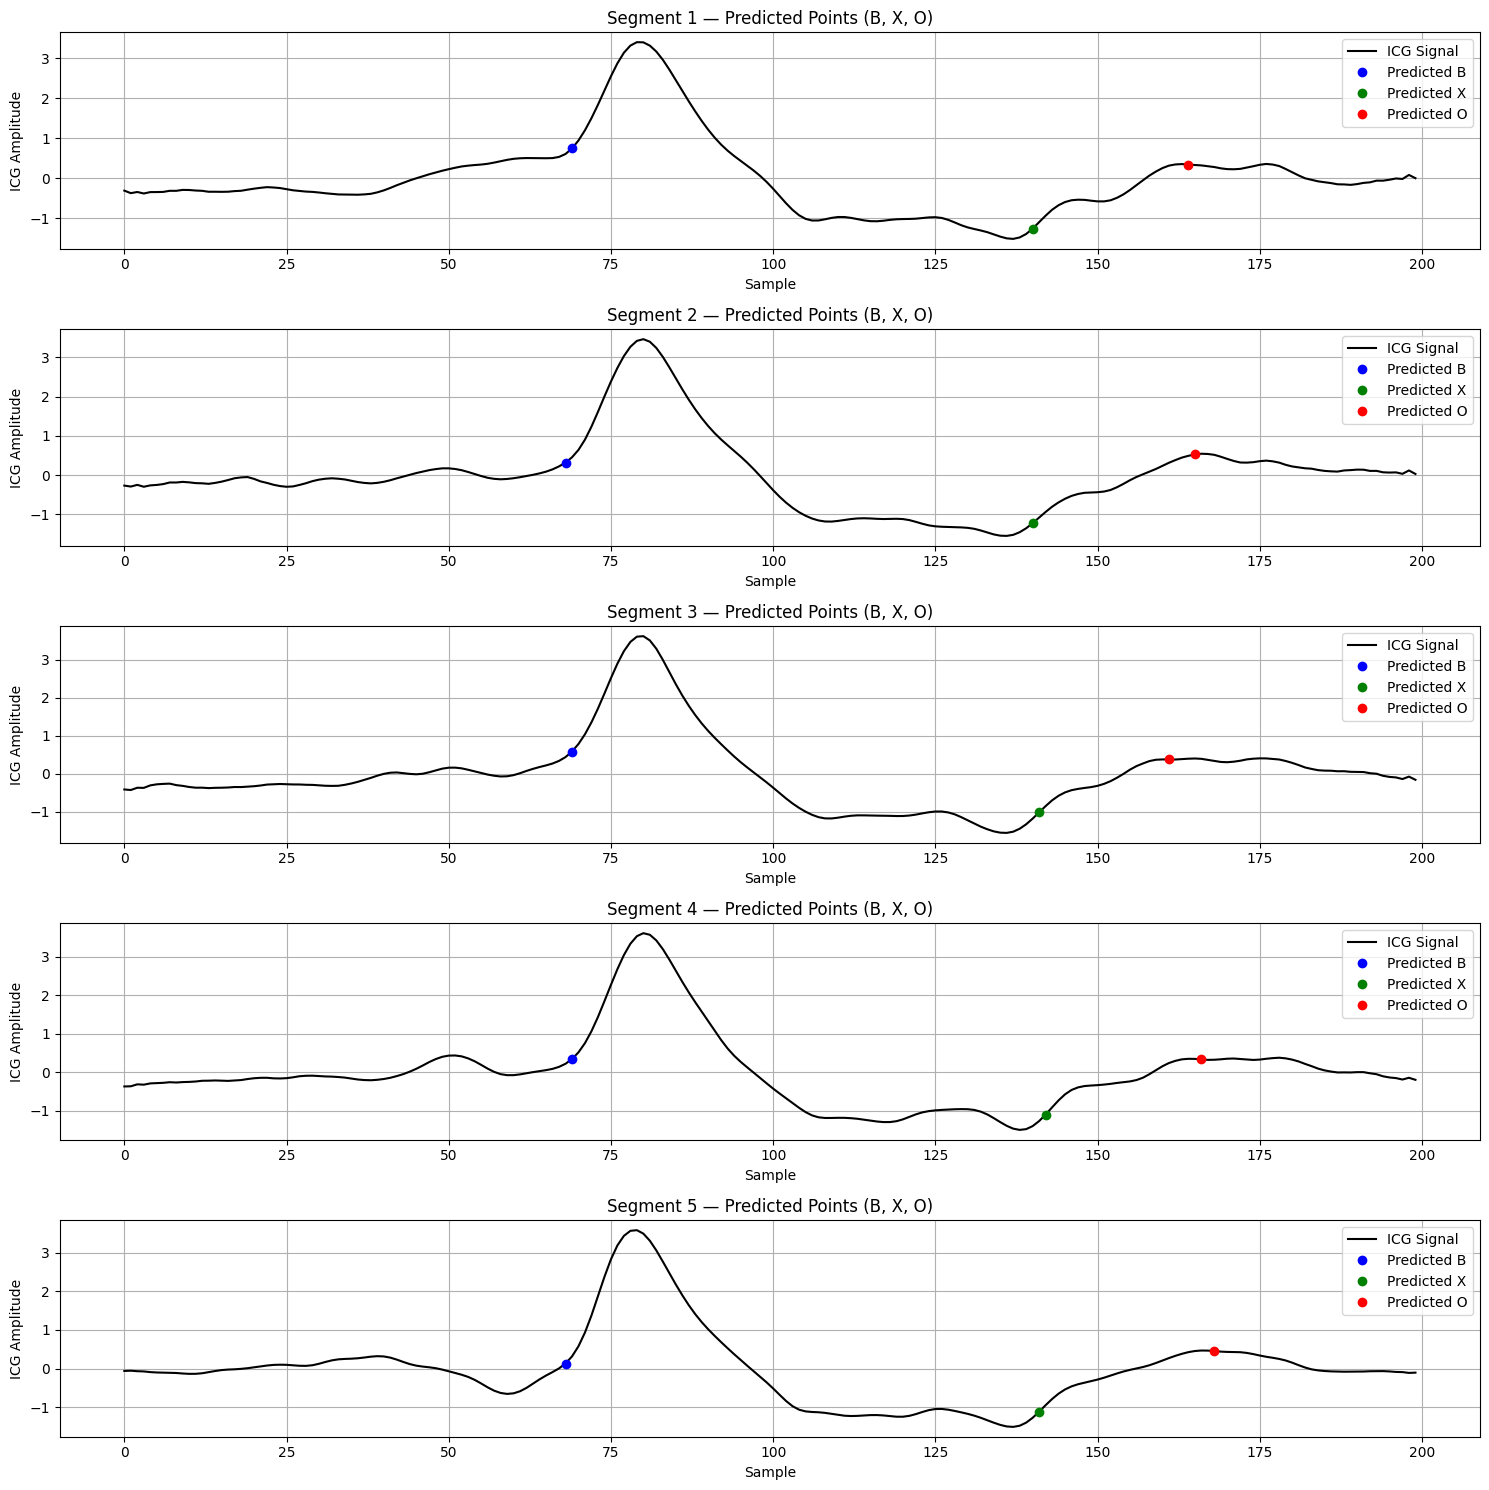

In [ ]:
# 4. Split channels
icg_segments_all = X_all[:, :, 0]
ecg_segments_all = X_all[:, :, 1]

# 5. Normalize per segment
X_input_all = create_model_input(ecg_segments_all, icg_segments_all)

# 6. Load trained model
predictor = load_model(model, compile=False)

# 7. Predict
y_pred_all = predictor.predict(X_input_all)  # shape: (n segments, 200, 3)

# 8. Extract predicted time indices for B, X, O
predicted_labels_all = extract_predicted_points(y_pred_all)  # shape: (628, 3)

# 9. Plot a few segments
plot_icg_with_predicted_points(X_input_all[:, :, 0], predicted_labels_all, n_segments_to_plot=5)

## C peak detection

In [ ]:
def detect_c_peak_after_r(icg_segments, predicted_bxo, offset=50, fs=250):
    """
    Detect C peaks as the maximum in a window after the R-peak in each segment.

    Parameters:
        icg_segments: np.array of shape (n_segments, segment_len)
        predicted_bxo: np.array of shape (n_segments, 3)
        offset: index of R-peak in each segment
        fs: sampling frequency

    Returns:
        predicted_b_c_x_o: np.array of shape (n_segments, 4)
    """
    c_indices = []
    window_length = int(0.3 * fs)  # 100 ms

    for i in range(len(icg_segments)):
        seg = icg_segments[i]
        start = offset
        end = min(offset + window_length, len(seg))

        search_window = seg[start:end]
        if len(search_window) > 0:
            c_rel = np.argmax(search_window)
            c = start + c_rel
        else:
            c = offset  # fallback
        c_indices.append(c)

    c_indices = np.array(c_indices).reshape(-1, 1)  # shape (n_segments, 1)

    # Insert C between B and X
    predicted_b_c_x_o = np.concatenate([
        predicted_bxo[:, :1],  # B
        c_indices,             # C
        predicted_bxo[:, 1:]   # X, O
    ], axis=1)

    return predicted_b_c_x_o

In [ ]:
def plot_icg_with_predicted_bcxo(icg_segments, predicted_points, n_segments_to_plot=8, fs=250):
    """
    Plots ICG segments and marks predicted B, C, X, O points.
    X-axis is in seconds.

    Parameters:
        icg_segments: np.array of shape (n_segments, segment_len)
        predicted_points: np.array of shape (n_segments, 4)
        n_segments_to_plot: int, number of segments to plot
        fs: int, sampling frequency in Hz
    """
    labels = ['B', 'C', 'X', 'O']
    colors = ['blue', 'orange', 'green', 'red']
    time_axis = np.arange(icg_segments.shape[1]) / fs  # seconds

    plt.figure(figsize=(14, n_segments_to_plot * 3))
    for i in range(min(n_segments_to_plot, len(icg_segments))):
        plt.subplot(n_segments_to_plot, 1, i + 1)
        plt.plot(time_axis, icg_segments[i], label='ICG Signal', color='black')

        for j, (label_name, color) in enumerate(zip(labels, colors)):
            idx = predicted_points[i, j]
            if 0 <= idx < icg_segments.shape[1]:
                plt.plot(time_axis[idx], icg_segments[i, idx], 'o', color=color, label=f'Predicted {label_name}')

        plt.title(f'Segment {i+1} - Predicted Points (B, C, X, O)')
        plt.xlabel('Time (s)')
        plt.ylabel('ICG Amplitude')
        if i == 0:
            plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()


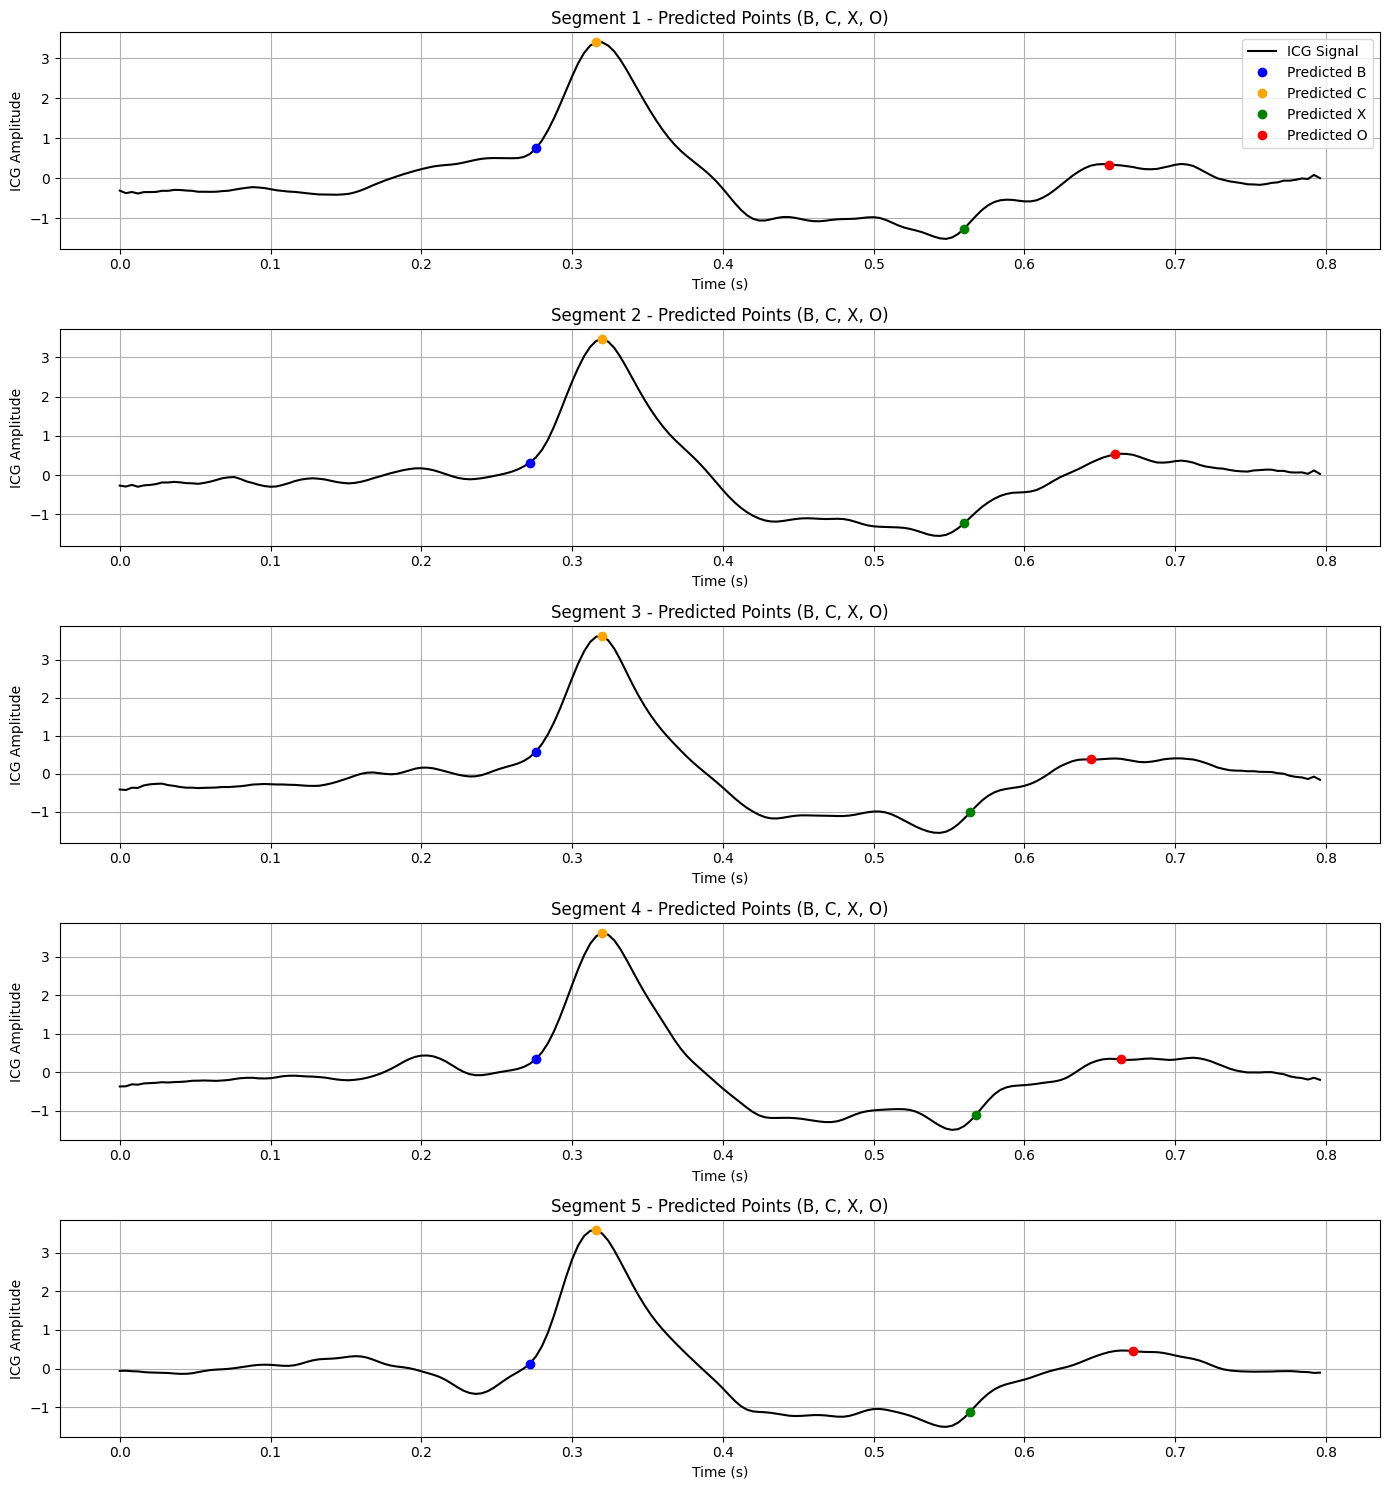

In [ ]:
# 1. Detect C peak
predicted_bcxo_all = detect_c_peak_after_r(X_input_all[:, :, 0], predicted_labels_all, offset=50, fs=250)

# 2. Plot all four points
plot_icg_with_predicted_bcxo(X_input_all[:, :, 0], predicted_bcxo_all, n_segments_to_plot=5)

In [ ]:
fs = 250
offset = int(0.2 * fs)  # R-peak index in segment (50 samples)

# Extract ICG signal
icg_segments_all = X_input_all[:, :, 0]  # shape: (n_segments, 200)
print("ICG segments shape:", icg_segments_all.shape)

# Detect B, C, X, O
predicted_b_c_x_o_all = detect_c_peak_after_r(
    icg_segments_all, predicted_labels_all, offset=offset, fs=fs
)

#Convert to float array for NaN support
corrected = predicted_b_c_x_o_all.astype(float)

# === Step 1: Flag bad X-points (too early after R-peak) ===
for i in range(len(corrected)):
    x = corrected[i, 2]
    if x < offset + int(0.1 * fs):  # 100ms after R-peak
        corrected[i, 2] = np.nan
        print(f"Flagged early X at segment {i}: original X = {x}")

# === Step 2: Flag bad B-points ===
min_pep = int(0.03 * fs)  # 30 ms
max_pep = int(0.13 * fs)  # 130 ms

bad_b_indices = []

for i in range(len(corrected)):
    b, c = corrected[i, 0], corrected[i, 1]

    if np.isnan(b) or np.isnan(c):
        bad_b_indices.append(i)
        continue

    if b < offset:  # before R-peak
        bad_b_indices.append(i)
        continue

    if b >= c:  # B after C
        bad_b_indices.append(i)
        continue

    pep = b - offset
    if pep < min_pep or pep > max_pep:
        bad_b_indices.append(i)

# Mark bad B-points as NaN
corrected[bad_b_indices, 0] = np.nan
print(f"Flagged {len(bad_b_indices)} bad B-points.")


ICG segments shape: (1155, 200)
Flagged early X at segment 299: original X = 36.0
Flagged early X at segment 446: original X = 5.0
Flagged early X at segment 705: original X = 27.0
Flagged early X at segment 794: original X = 28.0
Flagged early X at segment 815: original X = 27.0
Flagged early X at segment 1067: original X = 21.0
Flagged 18 bad B-points.


In [ ]:
def detect_physiological_outliers(y_bcxo, r_peaks):
    """
    Returns a dictionary with boolean masks indicating outliers per point (B, C, X, O),
    based on expected temporal order between points.

    Parameters:
        y_bcxo: np.ndarray of shape (n_samples, 4) — true B, C, X, O sample indices
        r_peaks: np.ndarray of shape (n_samples,) — R peak index for each segment

    Returns:
        outlier_masks: dict with keys 'B', 'C', 'X', 'O', each mapping to a boolean array (True = outlier)
    """
    B = y_bcxo[:, 0]
    C = y_bcxo[:, 1]
    X = y_bcxo[:, 2]
    O = y_bcxo[:, 3]
    R = r_peaks

    outliers = {}

    outliers['B'] = (B < R) | (B > C)
    outliers['C'] = (C < B) | (C > X)
    outliers['X'] = (X < C) | (X > O)
    outliers['O'] = (O < X)

    return outliers

# Compute R-peak index within each segment (0.2s offset at 250 Hz)
r_peaks_aligned = np.full(shape=(predicted_b_c_x_o_all.shape[0],), fill_value=50)
outliers = detect_physiological_outliers(predicted_b_c_x_o_all, r_peaks_aligned)

for point in ['B', 'C', 'X', 'O']:
    count = np.sum(outliers[point])
    percent = 100 * count / len(predicted_b_c_x_o_all)
    print(f"{point} outliers: {count} samples ({percent:.2f}%)")

B outliers: 10 samples (0.87%)
C outliers: 6 samples (0.52%)
X outliers: 64 samples (5.54%)
O outliers: 61 samples (5.28%)


In [ ]:
# 1. Combine outlier masks into a single mask (any point out of order)
combined_outliers = outliers['B'] | outliers['C'] | outliers['X'] | outliers['O']

# 2. Get indices of outlier segments
outlier_indices = np.where(combined_outliers)[0]

print(f"Total outlier segments: {len(outlier_indices)}")

# 3. Extract ICG segments and predicted points for these indices
icg_outlier_segments = icg_segments_all[outlier_indices]
predicted_outlier_points = predicted_b_c_x_o_all[outlier_indices]

#plot_icg_with_predicted_points(icg_outlier_segments, predicted_outlier_points, n_segments_to_plot=71)


Total outlier segments: 71


## Validation with hemodynamic parameters

In [ ]:
# Parameters
fs = 250
offset = int(0.2 * fs)  # 50 samples before R-peak

# Initialize result lists
pep_manual_all = []
pep_pred_all = []
lvet_manual_all = []
lvet_pred_all = []

# Detect outlier segments
outliers = detect_physiological_outliers(corrected, r_peaks_aligned)
valid_mask = ~(outliers['B'] | outliers['C'] | outliers['X'] | outliers['O'])
valid_indices = np.where(valid_mask)[0]
valid_index_map = {idx: i for i, idx in enumerate(valid_indices)}

segment_idx = 0  # global segment index in unfiltered data

for filename, data in all_data.items():
    try:
        pep_echo = np.array(data["pep_ms"])
        lvet_echo = np.array(data["lvet_ms"])
        n_segments = len(data["rpeaks_index"])

        # Global indices for this file's segments
        file_indices = list(range(segment_idx, segment_idx + n_segments))

        # Determine which segments in this file are valid
        valid_in_file = [i for i, global_idx in enumerate(file_indices) if global_idx in valid_index_map]

        if not valid_in_file:
            segment_idx += n_segments
            continue

        # Get corresponding predicted segments (still using unmodified corrected)
        corrected_indices = [valid_index_map[segment_idx + i] for i in valid_in_file]
        predicted_segments = corrected[valid_indices[corrected_indices]]
        pep_valid = pep_echo[valid_in_file]
        lvet_valid = lvet_echo[valid_in_file]

        pep_ms = []
        valid_pep_manual = []
        lvet_ms = []
        valid_lvet_manual = []

        for i, (b, c, x, o) in enumerate(predicted_segments):
            if not np.isnan(b):
                pep_time = ((b - offset) / fs) * 1000
                pep_ms.append(pep_time)
                valid_pep_manual.append(pep_valid[i])
            if not np.isnan(b) and not np.isnan(x):
                lvet_time = ((x - b) / fs) * 1000
                lvet_ms.append(lvet_time)
                valid_lvet_manual.append(lvet_valid[i])

        # Align lengths just in case
        min_len_pep = min(len(valid_pep_manual), len(pep_ms))
        min_len_lvet = min(len(valid_lvet_manual), len(lvet_ms))

        pep_manual_all.extend(valid_pep_manual[:min_len_pep])
        pep_pred_all.extend(pep_ms[:min_len_pep])
        lvet_manual_all.extend(valid_lvet_manual[:min_len_lvet])
        lvet_pred_all.extend(lvet_ms[:min_len_lvet])

        segment_idx += n_segments  # advance global counter

    except Exception as e:
        print(f"Error in file {filename}: {e}")
        continue

# Convert to arrays
pep_manual_all = np.array(pep_manual_all)
pep_pred_all = np.array(pep_pred_all)
lvet_manual_all = np.array(lvet_manual_all)
lvet_pred_all = np.array(lvet_pred_all)

# Round to nearest 5 ms
pep_pred_all_round = np.round(pep_pred_all / 5) * 5
lvet_pred_all_round = np.round(lvet_pred_all / 5) * 5

# Compute differences and MAEs
pep_diff = pep_pred_all_round - pep_manual_all
lvet_diff = lvet_pred_all_round - lvet_manual_all

pep_mae = np.mean(np.abs(pep_diff))
lvet_mae = np.mean(np.abs(lvet_diff))

# Print results
print("\n--- PEP ---")
print("PEP manual (ms):", pep_manual_all)
print("PEP predicted (ms):", pep_pred_all)
print("PEP predicted rounded (ms):", pep_pred_all_round)
print("PEP difference (ms):", pep_diff)
print(f"PEP MAE: {pep_mae:.2f} ms")

print("\n--- LVET ---")
print("LVET manual (ms):", lvet_manual_all)
print("LVET predicted (ms):", lvet_pred_all)
print("LVET predicted rounded (ms):", lvet_pred_all_round)
print("LVET difference (ms):", lvet_diff)
print(f"LVET MAE: {lvet_mae:.2f} ms")


--- PEP ---
PEP manual (ms): [110 110 100 ...  85  75  75]
PEP predicted (ms): [76. 72. 76. ... 52. 44. 40.]
PEP predicted rounded (ms): [75. 70. 75. ... 50. 45. 40.]
PEP difference (ms): [-35. -40. -25. ... -35. -30. -35.]
PEP MAE: 22.11 ms

--- LVET ---
LVET manual (ms): [275 275 285 ... 200 225 250]
LVET predicted (ms): [284. 288. 288. ... 264. 300. 264.]
LVET predicted rounded (ms): [285. 290. 290. ... 265. 300. 265.]
LVET difference (ms): [10. 15.  5. ... 65. 75. 15.]
LVET MAE: 42.29 ms


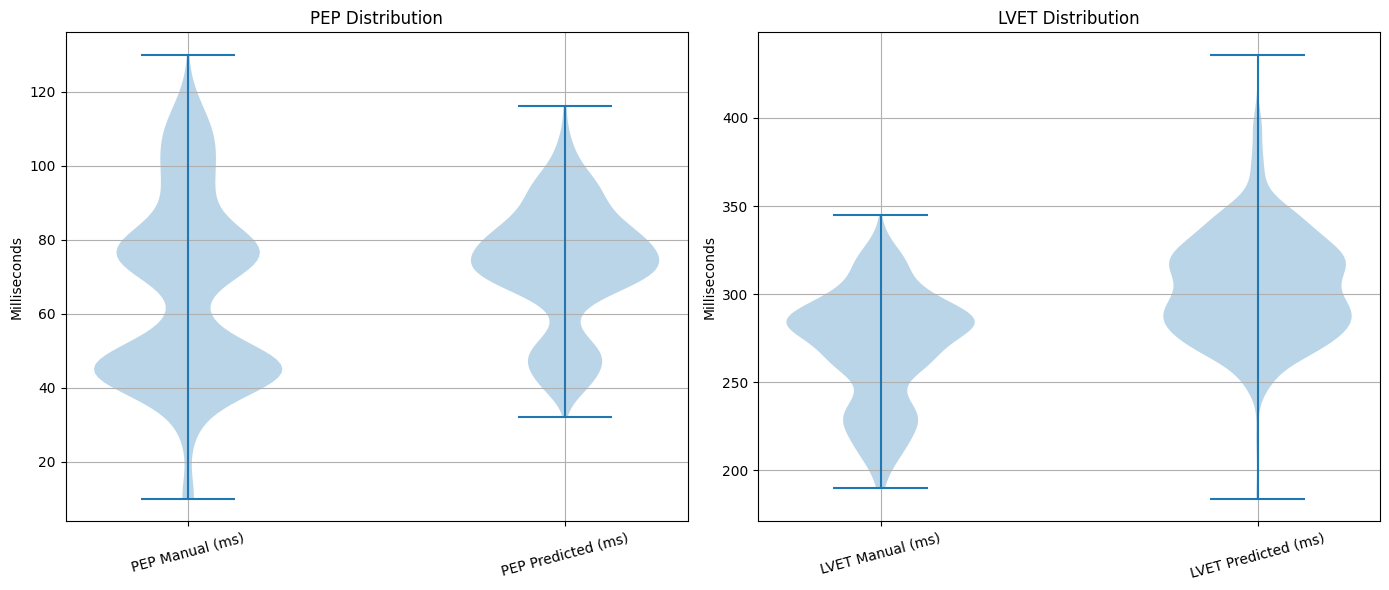

In [ ]:
pep_data = [pep_manual_all, pep_pred_all]
lvet_data = [lvet_manual_all, lvet_pred_all]

pep_labels = ['PEP Manual (ms)', 'PEP Predicted (ms)']
lvet_labels = ['LVET Manual (ms)', 'LVET Predicted (ms)']

# Set up plot
plt.figure(figsize=(14, 6))

# PEP boxplot
plt.subplot(1, 2, 1)
plt.violinplot(pep_data)
plt.xticks(ticks=[1, 2], labels=pep_labels, rotation=15)
plt.ylabel("Milliseconds")
plt.title("PEP Distribution")
plt.grid()

# LVET boxplot
plt.subplot(1, 2, 2)
plt.violinplot(lvet_data)
plt.xticks(ticks=[1, 2], labels=lvet_labels, rotation=15)
plt.ylabel("Milliseconds")
plt.title("LVET Distribution")
plt.grid()

plt.tight_layout()
plt.show()


In [ ]:
# Initialize per-subject metrics
per_subject_results = {}

segment_idx = 0
valid_indices = np.where(valid_mask)[0]
valid_index_map = {idx: i for i, idx in enumerate(valid_indices)}

for filename, data in all_data.items():
    try:
        # Manual measurements
        pep_echo = np.array(data["pep_ms"])
        lvet_echo = np.array(data["lvet_ms"])
        n_segments = len(data["rpeaks_index"])

        # Get global segment indices for this file
        file_segment_indices = list(range(segment_idx, segment_idx + n_segments))

        # Determine which of this file's segments are valid
        valid_in_file = [i for i, global_idx in enumerate(file_segment_indices) if global_idx in valid_index_map]

        # Skip file if no valid segments remain
        if not valid_in_file:
            segment_idx += n_segments
            continue

        # Select only the valid predicted segments for this file
        corrected_indices = [valid_index_map[segment_idx + i] for i in valid_in_file]
        predicted_segments = corrected[corrected_indices]

        # Select corresponding manual values
        pep_echo_valid = pep_echo[valid_in_file]
        lvet_echo_valid = lvet_echo[valid_in_file]

        pep_pred, lvet_pred = [], []

        for (b, c, x, o) in predicted_segments:
            pep_time = ((b - offset) / fs) * 1000
            lvet_time = ((x - b) / fs) * 1000
            pep_pred.append(pep_time)
            lvet_pred.append(lvet_time)
      # Convert to arrays
        pep_pred = np.array(pep_pred)
        lvet_pred = np.array(lvet_pred)

        # Align lengths (should already match, but just in case)
        min_len_pep = min(len(pep_echo_valid), len(pep_pred))
        min_len_lvet = min(len(lvet_echo_valid), len(lvet_pred))

        pep_manual = pep_echo_valid[:min_len_pep]
        pep_pred = pep_pred[:min_len_pep]
        lvet_manual = lvet_echo_valid[:min_len_lvet]
        lvet_pred = lvet_pred[:min_len_lvet]

        # Compute MAEs
        pep_mae = np.mean(np.abs(pep_pred - pep_manual))
        lvet_mae = np.mean(np.abs(lvet_pred - lvet_manual))

        # Store per-subject results
        per_subject_results[filename] = {
            "pep_manual": pep_manual,
            "pep_pred": pep_pred,
            "pep_diff": pep_pred - pep_manual,
            "pep_mae": pep_mae,
            "lvet_manual": lvet_manual,
            "lvet_pred": lvet_pred,
            "lvet_diff": lvet_pred - lvet_manual,
            "lvet_mae": lvet_mae,
            "n_segments": len(pep_manual)
        }

        segment_idx += n_segments

    except Exception as e:
        print(f"Error in file {filename}: {e}")
        continue

<ipython-input-22-2389356294>:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pep_maes, lvet_maes], patch_artist=True, labels=["PEP MAE", "LVET MAE"])


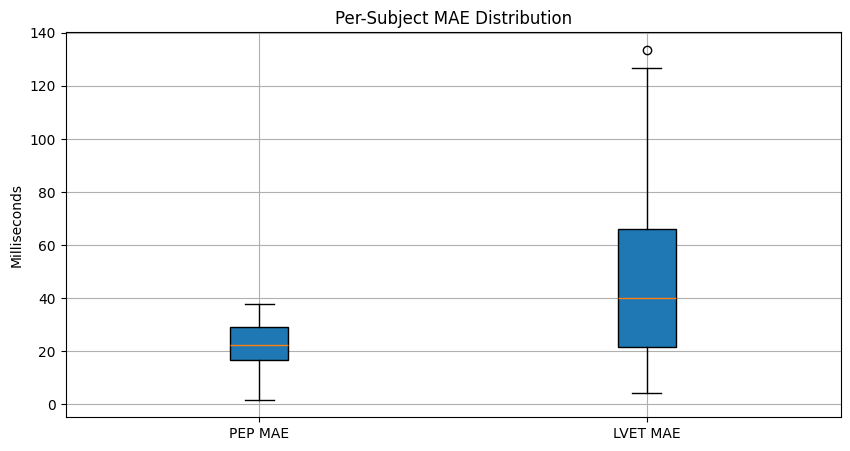

In [ ]:
pep_maes = [res["pep_mae"] for res in per_subject_results.values() if not np.isnan(res["pep_mae"])]
lvet_maes = [res["lvet_mae"] for res in per_subject_results.values() if not np.isnan(res["lvet_mae"])]

# Plot
plt.figure(figsize=(10, 5))
plt.boxplot([pep_maes, lvet_maes], patch_artist=True, labels=["PEP MAE", "LVET MAE"])
plt.title("Per-Subject MAE Distribution")
plt.ylabel("Milliseconds")
plt.grid(True)
plt.show()

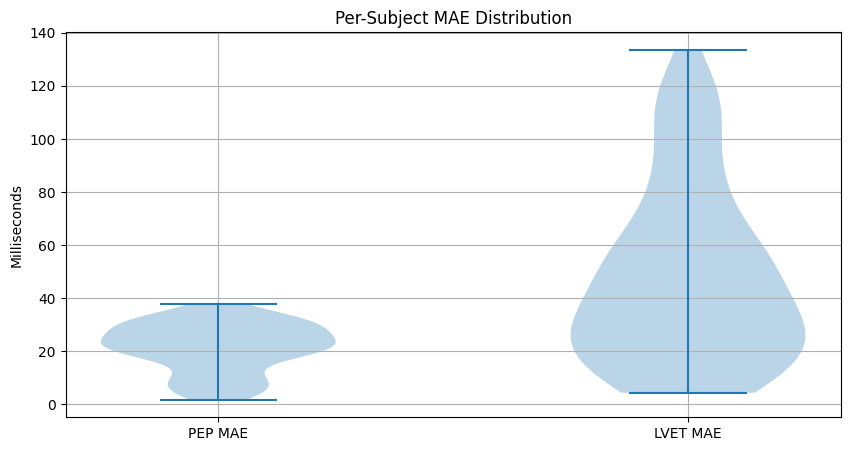

In [ ]:
pep_maes = [res["pep_mae"] for res in per_subject_results.values() if not np.isnan(res["pep_mae"])]
lvet_maes = [res["lvet_mae"] for res in per_subject_results.values() if not np.isnan(res["lvet_mae"])]

# Plot
plt.figure(figsize=(10, 5))
plt.violinplot([pep_maes, lvet_maes], positions=[0, 1])
plt.xticks([0, 1], ['PEP MAE', 'LVET MAE'])
plt.title("Per-Subject MAE Distribution")
plt.ylabel("Milliseconds")
plt.grid(True)
plt.show()


In [ ]:
# --- PEP: % within 20ms and 40ms ---
pep_within_20 = np.nanmean(np.abs(pep_diff) <= 20) * 100
pep_within_40 = np.nanmean(np.abs(pep_diff) <= 40) * 100

# --- LVET: % within 60ms and 80ms ---
lvet_within_60 = np.nanmean(np.abs(lvet_diff) <= 60) * 100
lvet_within_80 = np.nanmean(np.abs(lvet_diff) <= 80) * 100

print(f"\n--- PEP ---")
print("Within ±20 ms: {:.2f}%".format(pep_within_20))
print("Within ±40 ms: {:.2f}%".format(pep_within_40))

print(f"\n--- LVET ---")
print("Within ±60 ms: {:.2f}%".format(lvet_within_60))
print("Within ±80 ms: {:.2f}%".format(lvet_within_80))


--- PEP ---
Within ±20 ms: 48.75%
Within ±40 ms: 91.30%

--- LVET ---
Within ±60 ms: 74.91%
Within ±80 ms: 86.52%


In [ ]:
import pandas as pd
import numpy as np

# Build a detailed DataFrame per subject
subject_detailed_df = pd.DataFrame([
    {
        "Subject": fname,
        "Num Segments": res["n_segments"],
        "PEP MAE (ms)": np.round(res["pep_mae"], 2),
        "LVET MAE (ms)": np.round(res["lvet_mae"], 2),
        "Mean PEP (Manual)": np.round(np.mean(res["pep_manual"]), 2),
        "Mean PEP (Predicted)": np.round(np.mean(res["pep_pred"]), 2),
        "Mean LVET (Manual)": np.round(np.mean(res["lvet_manual"]), 2),
        "Mean LVET (Predicted)": np.round(np.mean(res["lvet_pred"]), 2),
    }
    for fname, res in per_subject_results.items()
    if not np.isnan(res["pep_mae"]) and not np.isnan(res["lvet_mae"])
])

# Optional: sort by subject name
subject_detailed_df = subject_detailed_df.sort_values("Subject").reset_index(drop=True)

# Display the table
subject_detailed_df

,Subject,Num Segments,PEP MAE (ms),LVET MAE (ms),Mean PEP (Manual),Mean PEP (Predicted),Mean LVET (Manual),Mean LVET (Predicted)
0,59146237_s0000001.mat,2,36.00,11.00,110.00,74.00,275.00,286.00
1,59146237_s0000002.mat,9,25.78,6.67,102.22,76.44,283.33,289.33
2,59146237_s0000003.mat,10,24.50,10.20,102.50,78.00,280.00,288.40
3,59146237_s0000004.mat,9,18.67,9.00,102.22,83.56,283.89,283.56
4,59146237_s0000005.mat,10,19.50,4.40,107.50,88.00,278.00,277.60
...,...,...,...,...,...,...,...,...
121,CH17_59146239_s0000009.mat,8,20.38,72.88,80.62,101.00,251.88,316.00
122,CH17_59146239_s0000010.mat,7,22.14,57.14,77.86,97.71,244.29,300.57
123,CH17_59146239_s0000012.mat,8,16.38,61.00,80.62,97.00,247.50,308.50
124,CH17_59146239_s0000013.mat,8,19.00,69.50,80.00,96.00,235.00,304.50


In [ ]:
latex_table = subject_detailed_df.to_latex(
    index=False,
    longtable=True,
    caption="Per-subject Mean Absolute Error (MAE) and average values for PEP and LVET predictions.",
    label="tab:subject_detailed_mae",
    column_format="lrrrrrrr",  # One 'r' per numeric column
    float_format="%.2f"
)

# Save to .tex file
with open("subject_detailed_mae_table.tex", "w") as f:
    f.write("\\chapter{Appendix}\n")
    f.write(latex_table)

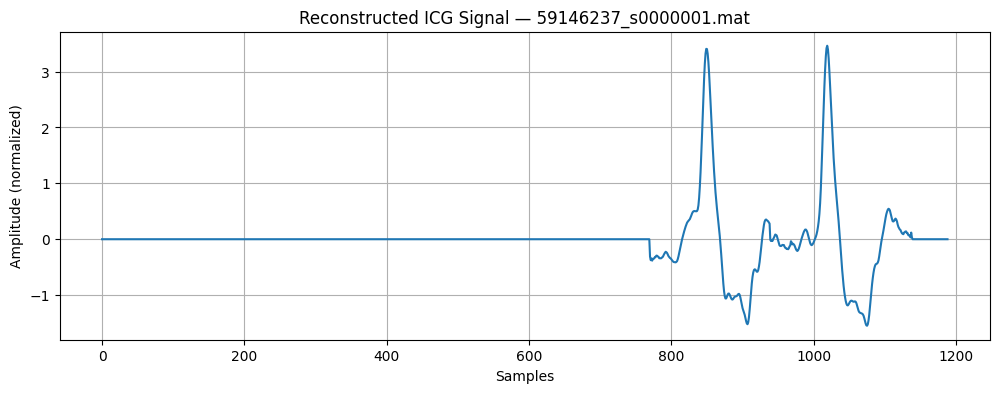

In [ ]:
fs = 250
offset = int(0.2 * fs)  # 50 samples
segment_length = X_input_all.shape[1]

# Seleccionar sujeto
subject_name = list(all_data.keys())[0]
subject_data = all_data[subject_name]
rpeaks = subject_data["rpeaks_index"]
n_segments = len(rpeaks)

# Buscar índice global de inicio de este sujeto en X_input_all
segment_idx = 0
for name in list(all_data.keys()):
    if name == subject_name:
        break
    segment_idx += len(all_data[name]["rpeaks_index"])

# Extraer segmentos ICG del sujeto
icg_subject_segments = X_input_all[segment_idx:segment_idx + n_segments, :, 0]  # canal 0 = ICG

# Estimar la longitud de la señal original (último R-peak + 1 ciclo)
estimated_length = rpeaks[-1] + int(0.8 * fs)
icg_full = np.zeros(estimated_length)
count = np.zeros(estimated_length)

# Reconstrucción con solapamiento y promedio
for seg, rpeak in zip(icg_subject_segments, rpeaks):
    start = rpeak - offset
    end = start + segment_length

    if start < 0 or end > len(icg_full):
        continue  # ignorar segmentos incompletos al inicio/final

    icg_full[start:end] += seg
    count[start:end] += 1

# Promediar zonas solapadas
icg_full_avg = np.divide(icg_full, count, out=np.zeros_like(icg_full), where=(count != 0))


plt.figure(figsize=(12, 4))
#plt.plot(icg_full)
plt.plot(icg_full_avg)
plt.title(f"Reconstructed ICG Signal — {subject_name}")
plt.xlabel("Samples")
plt.ylabel("Amplitude (normalized)")
plt.grid(True)
plt.show()


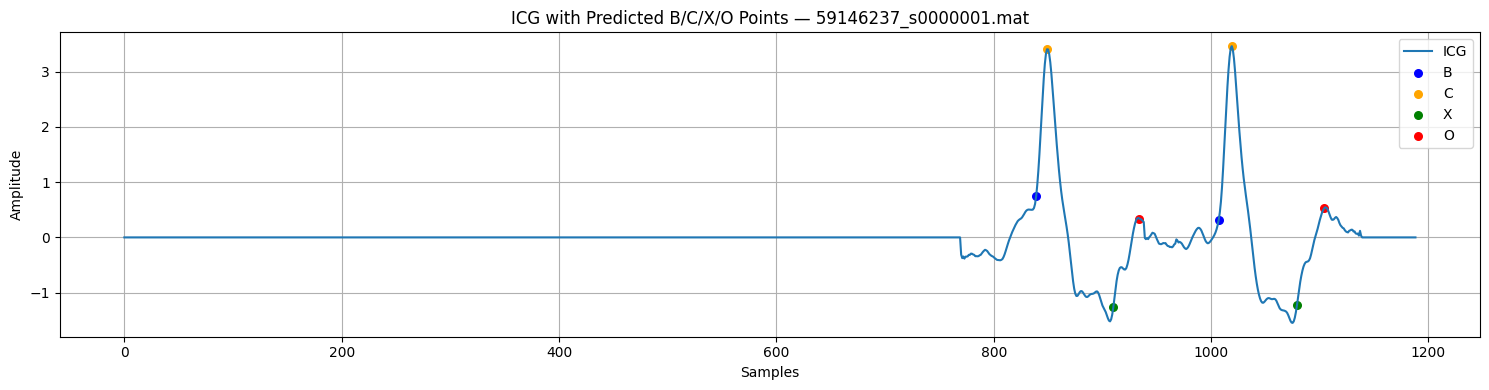

In [ ]:
predicted_subject = predicted_b_c_x_o_all[segment_idx:segment_idx + n_segments]

b_points = []
c_points = []
x_points = []
o_points = []

for (b, c, x, o), rpeak in zip(predicted_subject, rpeaks):
    if not np.isnan(b):
        b_points.append(int(rpeak - offset + b))
    if not np.isnan(c):
        c_points.append(int(rpeak - offset + c))
    if not np.isnan(x):
        x_points.append(int(rpeak - offset + x))
    if not np.isnan(o):
        o_points.append(int(rpeak - offset + o))

plt.figure(figsize=(15, 4))
plt.plot(icg_full_avg, label='ICG')

plt.scatter(b_points, icg_full_avg[b_points], color='blue', label='B', s=30)
plt.scatter(c_points, icg_full_avg[c_points], color='orange', label='C', s=30)
plt.scatter(x_points, icg_full_avg[x_points], color='green', label='X', s=30)
plt.scatter(o_points, icg_full_avg[o_points], color='red', label='O', s=30)

plt.title(f"ICG with Predicted B/C/X/O Points — {subject_name}")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# calculate RR intervals in milliseconds
rr_intervals_ms = np.diff(rpeaks_index) * 1000 / fs
print("RR intervals (ms):")
print(rr_intervals_ms)
print("Total RR intervals:", len(rr_intervals_ms))
print('Mean RR interval:', np.mean(rr_intervals_ms), 'ms')

RR intervals (ms):
[576. 604. 604. 568. 548. 576. 564. 564. 540. 592.]
Total RR intervals: 10
Mean RR interval: 573.6 ms


In [ ]:
# Calculate standard deviation of rr_intervals_ms
std_rr_intervals_ms = np.std(rr_intervals_ms)
print("Standard Deviation of RR intervals:", std_rr_intervals_ms, "ms")

Standard Deviation of RR intervals: 20.489997559785117 ms


In [ ]:
def plot_poincare_intervals(intervals_dict, rr_intervals_ms=None):
    """
    Generate Poincaré plots for each type of interval (R-R, B-B, C-C, X-X, O-O).

    Parameters:
        intervals_dict: Dictionary with keys 'B', 'C', 'X', 'O' and values as np.arrays of intervals (ms)
        rr_intervals_ms: Optional np.array of R-R intervals in ms
    """
    all_intervals = {}
    if rr_intervals_ms is not None:
        all_intervals['R'] = rr_intervals_ms
    all_intervals.update(intervals_dict)

    for label, intervals in all_intervals.items():
        if len(intervals) < 2:
            print(f"Skipping {label}-{label} (not enough data)")
            continue

        x = intervals[:-1]
        y = intervals[1:]

        plt.figure(figsize=(6, 6))
        plt.scatter(x, y, alpha=0.5)
        min_val = min(min(x), min(y))
        max_val = max(max(x), max(y))
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Line of Identity')
        plt.xlabel(f'{label}-{label}(n) [ms]')
        plt.ylabel(f'{label}-{label}(n+1) [ms]')
        plt.title(f'Poincaré Plot of {label}-{label} Intervals')
        plt.axis('equal')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


In [ ]:
# # Compute RR intervals from R-peaks
# rr_intervals_ms = np.diff(rpeaks_index) * 1000 / fs

# # Generate Poincaré plots
# plot_poincare_intervals(intervals_dict, rr_intervals_ms)

#AVO AVC

In [ ]:
fs = 250
offset = int(0.2 * fs)  # R-peak index in segment (50 samples)

# Extract ICG signal
icg_segments_all = X_input_all[:, :, 0]  # shape: (n_segments, 200)
print("ICG segments shape:", icg_segments_all.shape)

# Detect B, C, X, O (C estimated after R-peak)
predicted_b_c_x_o_all = detect_c_peak_after_r(
    icg_segments_all, predicted_labels_all, offset=offset, fs=fs
)

# Convert to float array for NaN support
corrected = predicted_b_c_x_o_all.astype(float)

# === Step 1: Flag bad X-points (too early after R-peak) ===
min_x_after_r = offset + int(0.1 * fs)  # 100 ms after R
bad_x_indices = []

for i in range(len(corrected)):
    x = corrected[i, 2]
    if x < min_x_after_r:
        corrected[i, 2] = np.nan
        bad_x_indices.append(i)
        print(f"Flagged early X at segment {i}: original X = {x}")

# === Step 2: Flag bad B-points ===
min_pep = int(0.03 * fs)  # 30 ms
max_pep = int(0.13 * fs)  # 130 ms
bad_b_indices = []

for i in range(len(corrected)):
    b, c = corrected[i, 0], corrected[i, 1]

    if np.isnan(b) or np.isnan(c):
        bad_b_indices.append(i)
        continue

    if b < offset:  # B before R-peak
        bad_b_indices.append(i)
        continue

    if b >= c:  # B after or equal to C
        bad_b_indices.append(i)
        continue

    pep = b - offset
    if pep < min_pep or pep > max_pep:
        bad_b_indices.append(i)

# Mark bad B-points as NaN
for idx in bad_b_indices:
    corrected[idx, 0] = np.nan

print(f"Flagged {len(bad_b_indices)} bad B-points.")
print(f"Flagged {len(bad_x_indices)} bad X-points.")

# === Combine all bad segments (B or X bad)
bad_segment_indices = sorted(set(bad_b_indices).union(bad_x_indices))
print(f"Total bad segments (union): {len(bad_segment_indices)}")
print(bad_segment_indices)

ICG segments shape: (1155, 200)
Flagged early X at segment 299: original X = 36.0
Flagged early X at segment 446: original X = 5.0
Flagged early X at segment 705: original X = 27.0
Flagged early X at segment 794: original X = 28.0
Flagged early X at segment 815: original X = 27.0
Flagged early X at segment 1067: original X = 21.0
Flagged 18 bad B-points.
Flagged 6 bad X-points.
Total bad segments (union): 23
[299, 446, 605, 705, 715, 794, 815, 1067, 1103, 1104, 1106, 1107, 1109, 1116, 1123, 1127, 1128, 1129, 1138, 1149, 1151, 1153, 1154]


In [ ]:
import numpy as np
from scipy.stats import pearsonr

def nan_safe_ccc(x_list, y_list):
    x = np.array(x_list)
    y = np.array(y_list)
    valid = ~np.isnan(x) & ~np.isnan(y)
    x = x[valid]
    y = y[valid]
    if len(x) < 2:
        return np.nan

    mean_x = np.mean(x)
    mean_y = np.mean(y)
    var_x = np.var(x)
    var_y = np.var(y)
    cov_xy = np.cov(x, y, bias=True)[0, 1]

    ccc = (2 * cov_xy) / (var_x + var_y + (mean_x - mean_y)**2)
    return ccc

fs = 250
pre_r = 0.2

bad_segment_indices = set(bad_segment_indices)

b_minus_avo = []
c_minus_avo = []
x_minus_avc = []
o_minus_avo = []
b_indices = []
c_indices = []
x_indices = []
o_indices = []

segment_counter = 0
for filename, data in all_data.items():
    rpeaks_time = data["rpeaks_time"]
    avo_time = data["avo_time"]
    avc_time = data["avc_time"]

    n_segments = len(rpeaks_time)
    for i in range(n_segments):
        if segment_counter >= len(corrected):
            break

        if segment_counter in bad_segment_indices:
            segment_counter += 1
            continue  # skip bad segments

        r_time = rpeaks_time[i]
        predicted_b = corrected[segment_counter, 0]
        predicted_c = corrected[segment_counter, 1]
        predicted_x = corrected[segment_counter, 2]
        predicted_o = corrected[segment_counter, 3]

        b_time = r_time - pre_r + (predicted_b / fs)
        c_time = r_time - pre_r + (predicted_c / fs)
        x_time = r_time - pre_r + (predicted_x / fs)
        o_time = r_time - pre_r + (predicted_o / fs)

        if i < len(avo_time) and i < len(avc_time):
            b_minus_avo.append(b_time - avo_time[i])
            c_minus_avo.append(c_time - avo_time[i])
            x_minus_avc.append(x_time - avc_time[i])
            o_minus_avo.append(o_time - avo_time[i])
            b_indices.append((b_time, avo_time[i]))
            c_indices.append((c_time, avo_time[i]))
            x_indices.append((x_time, avc_time[i]))
            o_indices.append((o_time, avo_time[i]))

        segment_counter += 1

# Convert differences to arrays
b_minus_avo = np.array(b_minus_avo)
c_minus_avo = np.array(c_minus_avo)
x_minus_avc = np.array(x_minus_avc)
o_minus_avo = np.array(o_minus_avo)

# Bias and std with NaN-safe functions
bias_b = np.nanmean(b_minus_avo)
bias_c = np.nanmean(c_minus_avo)
bias_x = np.nanmean(x_minus_avc)
bias_o = np.nanmean(o_minus_avo)

std_b = np.nanstd(b_minus_avo)
std_c = np.nanstd(c_minus_avo)
std_x = np.nanstd(x_minus_avc)
std_o = np.nanstd(o_minus_avo)

# NaN-safe Pearson correlation
# NaN-safe Lin's Concordance Correlation
b_times, avo_times = zip(*b_indices)
c_times, avo_times_c = zip(*c_indices)
x_times, avc_times = zip(*x_indices)
o_times, avo_times_o = zip(*o_indices)

ccc_b = nan_safe_ccc(b_times, avo_times)
ccc_c = nan_safe_ccc(c_times, avo_times_c)
ccc_x = nan_safe_ccc(x_times, avc_times)
ccc_o = nan_safe_ccc(o_times, avo_times_o)

# Mostrar resultados
print("Bias (B - AVO):", bias_b, "±", std_b, "s")
print("Bias (C - AVO):", bias_c, "±", std_c, "s")
print("Bias (X - AVC):", bias_x, "±", std_x, "s")
print("Bias (O - AVC):", bias_o, "±", std_o, "s")

print("Lin’s CCC (B vs AVO):", ccc_b)
print("Lin’s CCC (C vs AVO):", ccc_c)
print("Lin’s CCC (X vs AVC):", ccc_x)
print("Lin’s CCC (O vs AVC):", ccc_o)



Bias (B - AVO): 0.009129336707775385 ± 0.04503042412621697 s
Bias (C - AVO): 0.05268410702579657 ± 0.04538977538776353 s
Bias (X - AVC): 0.11392527310353502 ± 0.06724646981481774 s
Bias (O - AVC): 0.4069597254003548 ± 0.11071273691571865 s
Lin’s CCC (B vs AVO): 0.9998063086037083
Lin’s CCC (C vs AVO): 0.9995561872843346
Lin’s CCC (X vs AVC): 0.9983988886813816
Lin’s CCC (O vs AVC): 0.9839343677365872


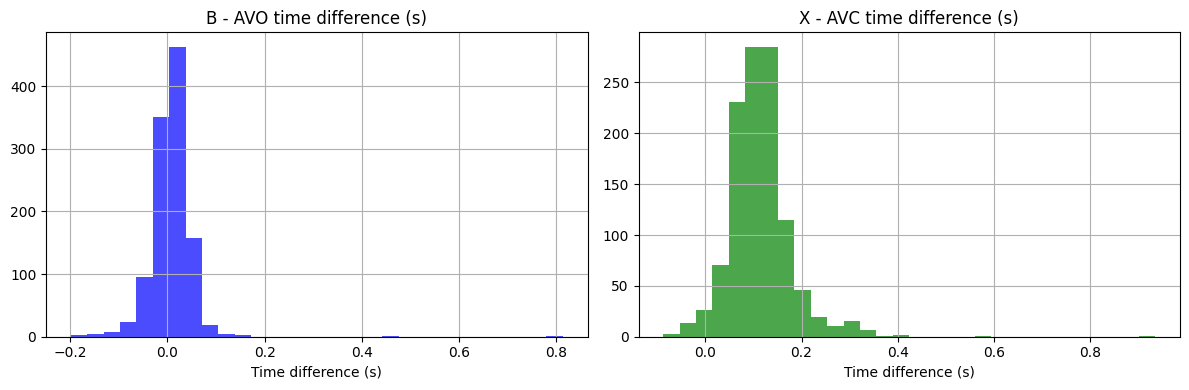

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(b_minus_avo[~np.isnan(b_minus_avo)], bins=30, color='blue', alpha=0.7)
plt.title("B - AVO time difference (s)")
plt.xlabel("Time difference (s)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist(x_minus_avc[~np.isnan(x_minus_avc)], bins=30, color='green', alpha=0.7)
plt.title("X - AVC time difference (s)")
plt.xlabel("Time difference (s)")
plt.grid(True)

plt.tight_layout()
plt.show()


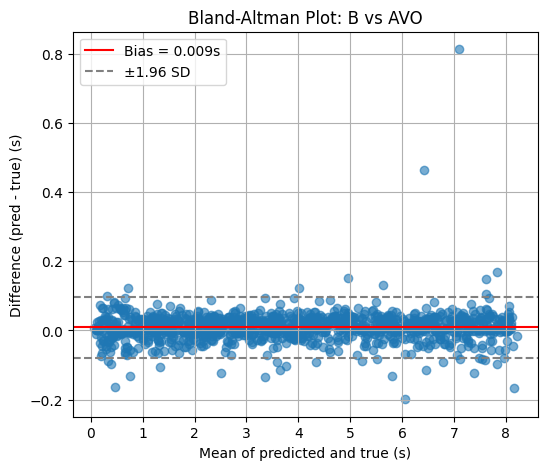

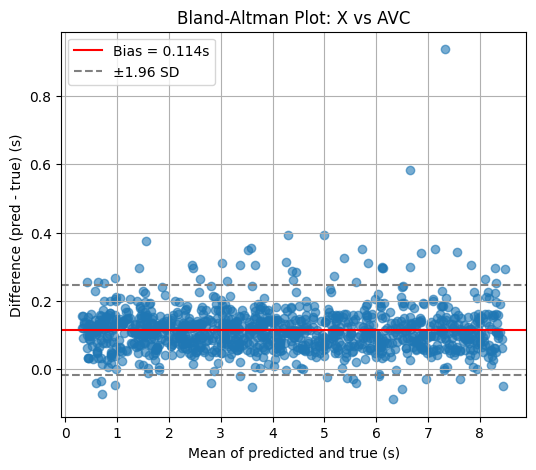

In [ ]:
def bland_altman_plot(pred, true, label):
    pred = np.array(pred)
    true = np.array(true)
    valid = ~np.isnan(pred) & ~np.isnan(true)

    pred = pred[valid]
    true = true[valid]

    mean = (pred + true) / 2
    diff = pred - true
    bias = np.mean(diff)
    loa = 1.96 * np.std(diff)

    plt.figure(figsize=(6, 5))
    plt.scatter(mean, diff, alpha=0.6)
    plt.axhline(bias, color='red', label=f'Bias = {bias:.3f}s')
    plt.axhline(bias + loa, color='gray', linestyle='--', label='±1.96 SD')
    plt.axhline(bias - loa, color='gray', linestyle='--')
    plt.xlabel("Mean of predicted and true (s)")
    plt.ylabel("Difference (pred - true) (s)")
    plt.title(f"Bland-Altman Plot: {label}")
    plt.legend()
    plt.grid(True)
    plt.show()

bland_altman_plot(b_times, avo_times, "B vs AVO")
bland_altman_plot(x_times, avc_times, "X vs AVC")

In [ ]:
def bland_altman_plot_no_outliers(pred, true, label):
    pred = np.array(pred)
    true = np.array(true)
    valid = ~np.isnan(pred) & ~np.isnan(true)

    pred = pred[valid]
    true = true[valid]

    mean = (pred + true) / 2
    diff = pred - true
    bias = np.mean(diff)
    std = np.std(diff)
    loa = 1.96 * std

    # Filter: only keep differences within ±1.96 SD
    inliers = (diff >= (bias - loa)) & (diff <= (bias + loa))
    mean = mean[inliers]
    diff = diff[inliers]

    # Recalculate bias and SD with inliers only (optional)
    bias_filtered = np.mean(diff)
    std_filtered = np.std(diff)

    plt.figure(figsize=(6, 5))
    plt.scatter(mean, diff, alpha=0.6)
    plt.axhline(bias_filtered, color='red', label=f'Bias = {bias_filtered:.3f}s')
    plt.axhline(bias_filtered + 1.96 * std_filtered, color='gray', linestyle='--', label='±1.96 SD')
    plt.axhline(bias_filtered - 1.96 * std_filtered, color='gray', linestyle='--')
    plt.xlabel("Mean of predicted and true (s)")
    plt.ylabel("Difference (pred - true) (s)")
    plt.title(f"Bland-Altman Plot (Filtered): {label}")
    plt.legend()
    plt.grid(True)
    plt.show()


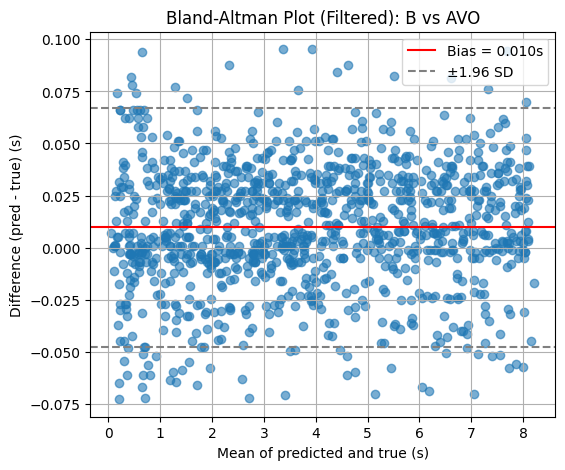

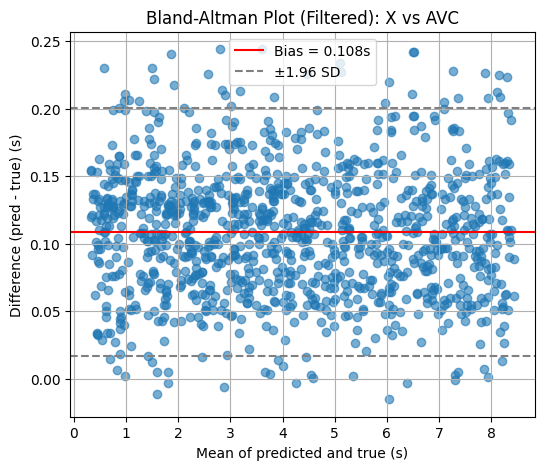

In [ ]:
bland_altman_plot_no_outliers(b_times, avo_times, "B vs AVO")
bland_altman_plot_no_outliers(x_times, avc_times, "X vs AVC")


In [ ]:
import numpy as np

def count_outliers(pred, true):
    pred = np.array(pred)
    true = np.array(true)
    valid = ~np.isnan(pred) & ~np.isnan(true)

    pred = pred[valid]
    true = true[valid]

    diff = pred - true
    bias = np.mean(diff)
    std = np.std(diff)
    loa = 1.96 * std

    # Find outliers
    outliers = (diff < (bias - loa)) | (diff > (bias + loa))
    num_outliers = np.sum(outliers)
    total = len(diff)

    print(f"Total points: {total}")
    print(f"Outliers (outside ±1.96 SD): {num_outliers}")
    print(f"Percentage discarded: {100 * num_outliers / total:.2f}%")

    return num_outliers, total

# Apply to B and X comparisons
print("B vs AVO outliers:")
count_outliers(b_times, avo_times)

print("\nX vs AVC outliers:")
count_outliers(x_times, avc_times)


B vs AVO outliers:
Total points: 1132
Outliers (outside ±1.96 SD): 35
Percentage discarded: 3.09%

X vs AVC outliers:
Total points: 1132
Outliers (outside ±1.96 SD): 57
Percentage discarded: 5.04%


(np.int64(57), 1132)

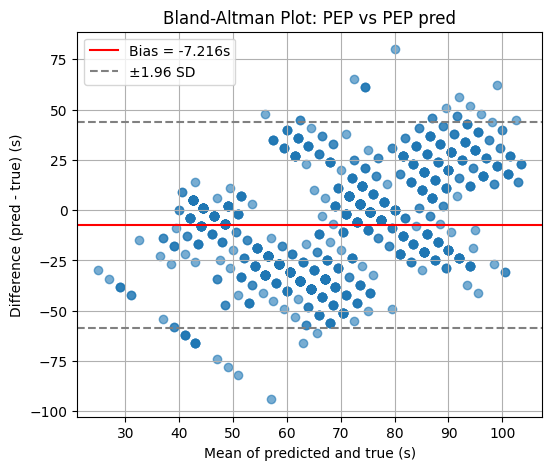

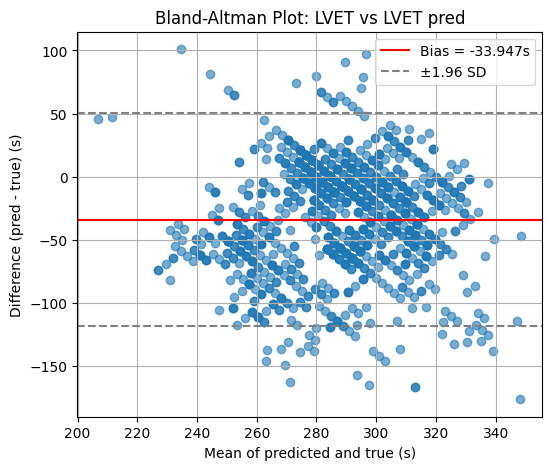

In [ ]:

bland_altman_plot(pep_manual_all, pep_pred_all, "PEP vs PEP pred")
bland_altman_plot(lvet_manual_all, lvet_pred_all, "LVET vs LVET pred")


In [ ]:
def bland_altman_stats(diff, label=""):
    bias = np.mean(diff)
    std = np.std(diff)
    lower_loa = bias - 1.96 * std
    upper_loa = bias + 1.96 * std
    outliers = np.sum((diff < lower_loa) | (diff > upper_loa)) / len(diff)

    print(f"--- Bland-Altman Analysis: {label} ---")
    print(f"Bias: {bias:.6f} s")
    print(f"Standard deviation: {std:.6f} s")
    print(f"Limits of agreement: [{lower_loa:.6f}, {upper_loa:.6f}] s")
    print(f"Outliers beyond LoA: {outliers * 100:.2f}%\n")

# Run for both B–AVO and X–AVC
bland_altman_stats(np.array(b_minus_avo), label="B vs AVO")
bland_altman_stats(np.array(x_minus_avc), label="X vs AVC")


--- Bland-Altman Analysis: B vs AVO ---
Bias: 0.009129 s
Standard deviation: 0.045030 s
Limits of agreement: [-0.079130, 0.097389] s
Outliers beyond LoA: 3.09%

--- Bland-Altman Analysis: X vs AVC ---
Bias: 0.113925 s
Standard deviation: 0.067246 s
Limits of agreement: [-0.017878, 0.245728] s
Outliers beyond LoA: 5.04%



# Validation with hemodynamic parameters CHC01

In [ ]:
import os
import scipy.io as sio
import numpy as np

# List of target filenames
target_filenames = [
    "59146238_s0000058", "59146237_s0000059", "59146237_s0000060",
    "59146237_s0000061", "59146237_s0000062", "59146237_s0000063",
    "59146237_s0000064", "59146237_s0000065", "59146237_s0000066",
    "59146237_s0000067", "59146237_s0000068", "59146237_s0000069",
    "59146237_s0000070", "59146237_s0000071", "59146237_s0000072",
    "59146237_s0000073", "59146237_s0000074", "59146237_s0000075",
    "59146237_s0000076", "59146237_s0000077", "59146237_s0000078",
    "59146238_s0000079", "59146238_s0000080", "59146238_s0000081",
    "59146238_s0000082", "59146238_s0000083", "59146238_s0000084"
]

# Base directory
base_dir = "/content/drive/MyDrive/TFG/Data_HeartCycle"

# Output lists
chc01_list = []
chc01_segment_map = {}  # filename → (start_idx, end_idx)
segment_index = 0

for filename in target_filenames:
    subject_id = filename.split("_")[0]
    file_path = os.path.join(base_dir, subject_id, filename + ".mat")

    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        continue

    try:
        data_hc = sio.loadmat(file_path)

        if 'measure' not in data_hc:
            print(f"No 'measure' key in {filename}")
            continue

        measures = data_hc['measure']

        # Extract signals
        icg = measures[1, 1]
        icg_time = icg['time'][0, 0].flatten()
        icg_data = icg['data'][0, 0].flatten()

        ecg = measures[0, 1]
        ecg_time = ecg['time'][0, 0].flatten()
        ecg_data = ecg['data'][0, 0].flatten()

        rpeaks = measures[2, 1]
        rpeaks_times = rpeaks['data'][0, 0].flatten()
        rpeaks_indices = np.array([np.argmin(np.abs(ecg_time - t)) for t in rpeaks_times])

        # Preprocess
        dz_dt_norm, ecg_norm = preprocess_signals(
            icg_data=icg_data,
            icg_time=icg_time,
            ecg_data=ecg_data,
            fs_icg=200,
            fs_ecg=200
        )

        # Segment and prepare input
        icg_segments = segment_icg(dz_dt_norm, rpeaks_indices, fs=200)
        ecg_segments = segment_icg(ecg_norm, rpeaks_indices, fs=200)

        icg_segments_up = upsample_segments(icg_segments, from_fs=200, to_fs=250)
        ecg_segments_up = upsample_segments(ecg_segments, from_fs=200, to_fs=250)

        X_input = prepare_icg_model_input(icg_segments_up, ecg_segments_up)

        # Track segment index range for this file
        num_segments = X_input.shape[0]
        chc01_segment_map[filename] = (segment_index, segment_index + num_segments)
        segment_index += num_segments

        chc01_list.append(X_input)

        print(f"{filename}: added {num_segments} segments")

    except Exception as e:
        print(f"Error loading {filename}: {e}")
        continue

# Final stack
chc01 = np.vstack(chc01_list) if chc01_list else np.empty((0, 200, 2))
print("Final chc01 shape:", chc01.shape)

# Split channels
icg_segments_chc01 = chc01[:, :, 0]
ecg_segments_chc01 = chc01[:, :, 1]

# Normalize per segment
X_input_chc01 = create_model_input(ecg_segments_chc01, icg_segments_chc01)

# Load trained model
predictor = load_model(model, compile=False)

# Predict
y_pred_chc01 = predictor.predict(X_input_chc01)  # shape: (n_segments, 200, 3)

# Extract predicted time indices for B, X, O
predicted_labels_chc01 = extract_predicted_points(y_pred_chc01)  # shape: (n_segments, 3)

# -----------------------------------------------------------
# Apply C-peak detection and filter invalid segments
# -----------------------------------------------------------
predicted_b_c_x_o_chc01 = detect_c_peak_after_r(icg_segments_chc01, predicted_labels_chc01, offset=offset, fs=fs)
corrected_chc01 = predicted_b_c_x_o_chc01.astype(float)

# Step 1: Remove early X points
for i in range(len(corrected_chc01)):
    x = corrected_chc01[i, 2]
    if x < offset + int(0.1 * fs):
        corrected_chc01[i, 2] = np.nan

# Step 2: Remove invalid B points
min_pep = int(0.03 * fs)
max_pep = int(0.13 * fs)
for i in range(len(corrected_chc01)):
    b, c = corrected_chc01[i, 0], corrected_chc01[i, 1]
    if np.isnan(b) or np.isnan(c) or b < offset or b >= c or not (min_pep <= b - offset <= max_pep):
        corrected_chc01[i, 0] = np.nan

# Step 3: Remove logical outliers
r_peaks_aligned = np.full(corrected_chc01.shape[0], offset)
outliers = detect_physiological_outliers(corrected_chc01, r_peaks_aligned)
valid_mask = ~(outliers['B'] | outliers['C'] | outliers['X'] | outliers['O'])
valid_indices = np.where(valid_mask)[0]
valid_index_map = {idx: i for i, idx in enumerate(valid_indices)}

# -----------------------------------------------------------
# Compute PEP and LVET only on valid segments
# -----------------------------------------------------------
pep_manual_all = []
pep_pred_all = []
lvet_manual_all = []
lvet_pred_all = []

for filename in target_filenames:
    filename_key = filename + ".mat"
    if filename_key not in all_data or filename not in chc01_segment_map:
        continue

    try:
        data = all_data[filename_key]
        pep_echo = np.array(data["pep_ms"])
        lvet_echo = np.array(data["lvet_ms"])

        start_idx, end_idx = chc01_segment_map[filename]
        file_indices = list(range(start_idx, end_idx))

        valid_in_file = [i for i, global_idx in enumerate(file_indices) if global_idx in valid_index_map]
        if not valid_in_file:
            continue

        corrected_indices = [valid_index_map[file_indices[i]] for i in valid_in_file]
        predicted_segments = corrected_chc01[valid_indices[corrected_indices]]

        pep_valid = pep_echo[valid_in_file]
        lvet_valid = lvet_echo[valid_in_file]

        pep_ms = []
        valid_pep_manual = []
        lvet_ms = []
        valid_lvet_manual = []

        for i, (b, c, x, o) in enumerate(predicted_segments):
            if not np.isnan(b):
                pep_time = ((b - offset) / fs) * 1000
                pep_ms.append(pep_time)
                valid_pep_manual.append(pep_valid[i])
            if not np.isnan(b) and not np.isnan(x):
                lvet_time = ((x - b) / fs) * 1000
                lvet_ms.append(lvet_time)
                valid_lvet_manual.append(lvet_valid[i])

        min_len_pep = min(len(valid_pep_manual), len(pep_ms))
        min_len_lvet = min(len(valid_lvet_manual), len(lvet_ms))

        pep_manual_all.extend(valid_pep_manual[:min_len_pep])
        pep_pred_all.extend(pep_ms[:min_len_pep])
        lvet_manual_all.extend(valid_lvet_manual[:min_len_lvet])
        lvet_pred_all.extend(lvet_ms[:min_len_lvet])

    except Exception as e:
        print(f"Error in file {filename}: {e}")
        continue

# Convert to arrays and round
pep_manual_all = np.array(pep_manual_all)
pep_pred_all = np.array(pep_pred_all)
lvet_manual_all = np.array(lvet_manual_all)
lvet_pred_all = np.array(lvet_pred_all)

pep_pred_all_round = np.round(pep_pred_all / 5) * 5
lvet_pred_all_round = np.round(lvet_pred_all / 5) * 5

pep_diff = pep_pred_all_round - pep_manual_all
lvet_diff = lvet_pred_all_round - lvet_manual_all

pep_mae = np.mean(np.abs(pep_diff)) if len(pep_diff) > 0 else np.nan
lvet_mae = np.mean(np.abs(lvet_diff)) if len(lvet_diff) > 0 else np.nan

# Results
print("\n--- PEP (chc01, filtered) ---")
print("PEP manual (ms):", pep_manual_all)
print("PEP predicted (ms):", pep_pred_all)
print("PEP predicted rounded (ms):", pep_pred_all_round)
print("PEP difference (ms):", pep_diff)
print(f"PEP MAE: {pep_mae:.2f} ms")

print("\n--- LVET (chc01, filtered) ---")
print("LVET manual (ms):", lvet_manual_all)
print("LVET predicted (ms):", lvet_pred_all)
print("LVET predicted rounded (ms):", lvet_pred_all_round)
print("LVET difference (ms):", lvet_diff)
print(f"LVET MAE: {lvet_mae:.2f} ms")

59146238_s0000058: added 5 segments
File not found: /content/drive/MyDrive/TFG/Data_HeartCycle/59146237/59146237_s0000059.mat
File not found: /content/drive/MyDrive/TFG/Data_HeartCycle/59146237/59146237_s0000060.mat
File not found: /content/drive/MyDrive/TFG/Data_HeartCycle/59146237/59146237_s0000061.mat
File not found: /content/drive/MyDrive/TFG/Data_HeartCycle/59146237/59146237_s0000062.mat
File not found: /content/drive/MyDrive/TFG/Data_HeartCycle/59146237/59146237_s0000063.mat
File not found: /content/drive/MyDrive/TFG/Data_HeartCycle/59146237/59146237_s0000064.mat
File not found: /content/drive/MyDrive/TFG/Data_HeartCycle/59146237/59146237_s0000065.mat
File not found: /content/drive/MyDrive/TFG/Data_HeartCycle/59146237/59146237_s0000066.mat
File not found: /content/drive/MyDrive/TFG/Data_HeartCycle/59146237/59146237_s0000067.mat
File not found: /content/drive/MyDrive/TFG/Data_HeartCycle/59146237/59146237_s0000068.mat
File not found: /content/drive/MyDrive/TFG/Data_HeartCycle/59146

<ipython-input-77-1ba169b08614>:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pep_maes, lvet_maes], patch_artist=True, labels=["PEP MAE", "LVET MAE"])


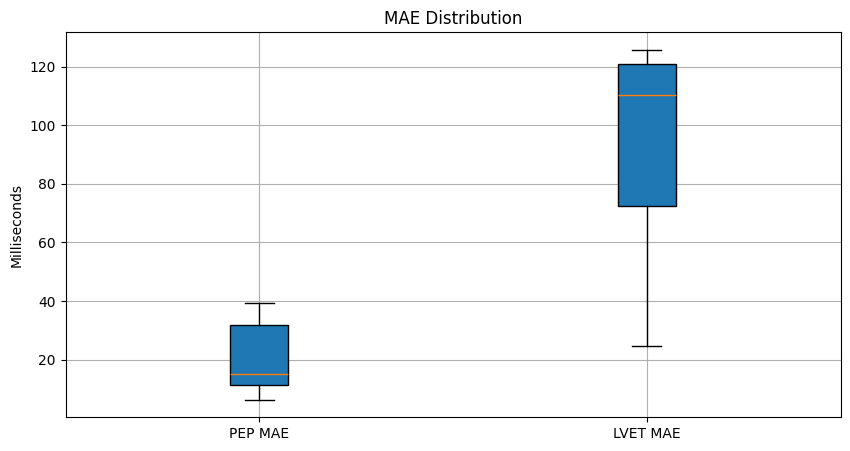

In [ ]:
pep_maes = [res["pep_mae"] for res in per_subject_results.values() if not np.isnan(res["pep_mae"])]
lvet_maes = [res["lvet_mae"] for res in per_subject_results.values() if not np.isnan(res["lvet_mae"])]

# Plot
plt.figure(figsize=(10, 5))
plt.boxplot([pep_maes, lvet_maes], patch_artist=True, labels=["PEP MAE", "LVET MAE"])
plt.title("MAE Distribution")
plt.ylabel("Milliseconds")
plt.grid(True)
plt.show()

In [ ]:
# --- PEP: % within 20ms and 40ms ---
pep_within_20 = np.nanmean(np.abs(pep_diff) <= 20) * 100
pep_within_40 = np.nanmean(np.abs(pep_diff) <= 40) * 100

# --- LVET: % within 60ms and 80ms ---
lvet_within_60 = np.nanmean(np.abs(lvet_diff) <= 60) * 100
lvet_within_80 = np.nanmean(np.abs(lvet_diff) <= 80) * 100

print(f"\n--- PEP ---")
print("Within ±20 ms: {:.2f}%".format(pep_within_20))
print("Within ±40 ms: {:.2f}%".format(pep_within_40))

print(f"\n--- LVET ---")
print("Within ±60 ms: {:.2f}%".format(lvet_within_60))
print("Within ±80 ms: {:.2f}%".format(lvet_within_80))


--- PEP ---
Within ±20 ms: 54.17%
Within ±40 ms: 100.00%

--- LVET ---
Within ±60 ms: 100.00%
Within ±80 ms: 100.00%


In [ ]:
import pandas as pd
import numpy as np

# Build a DataFrame
subject_df = pd.DataFrame([
    {
        "Subject": fname,
        "Num Segments": res["n_segments"],
        "PEP MAE (ms)": np.round(res["pep_mae"], 2),
        "LVET MAE (ms)": np.round(res["lvet_mae"], 2),
        "Mean PEP (manual)": np.round(np.mean(res["pep_manual"]), 2),
        "Mean LVET (manual)": np.round(np.mean(res["lvet_manual"]), 2)
    }
    for fname, res in per_subject_results.items()
    if not np.isnan(res["pep_mae"]) and not np.isnan(res["lvet_mae"])
])

# Display table
subject_df.sort_values("Subject").reset_index(drop=True)


,Subject,Num Segments,PEP MAE (ms),LVET MAE (ms),Mean PEP (manual),Mean LVET (manual)
0,59146238_s0000043,10,32.3,28.40,38.50,292.00
1,59146238_s0000044,10,33.9,28.80,38.50,292.00
2,59146238_s0000045,10,35.1,24.80,38.50,292.00
3,59146238_s0000046,10,30.5,70.20,38.50,292.00
4,59146238_s0000047,10,39.3,78.80,38.50,292.00
5,59146238_s0000048,10,6.3,121.70,41.50,213.50
6,59146238_s0000049,10,11.7,115.70,41.50,213.50
7,59146238_s0000050,10,9.1,120.50,41.50,213.50
8,59146238_s0000051,10,11.9,121.30,41.50,213.50
9,59146238_s0000052,9,11.0,124.44,41.67,213.33


In [ ]:
latex_table = subject_df.to_latex(
    index=False,
    longtable=True,
    caption="Per-subject Mean Absolute Error (MAE) for PEP and LVET prediction.",
    label="tab:subject_mae",
    column_format="lrrrrr",  # Adjust based on your columns
    float_format="%.2f"
)

# Save to file
with open("subject_mae_table.tex", "w") as f:
    f.write("\\chapter{Appendix}\n")
    f.write(latex_table)

# Validation with hemodynamic parameters CHC02

In [ ]:
import os
import scipy.io as sio
import numpy as np

# List of target filenames
target_filenames = [
    "59146238_s0000043",
    "59146238_s0000044",
    "59146238_s0000045",
    "59146238_s0000046",
    "59146238_s0000047",
    "59146238_s0000048",
    "59146238_s0000049",
    "59146238_s0000050",
    "59146238_s0000051",
    "59146238_s0000052",
    "59146238_s0000053",
    "59146238_s0000054",
    "59146238_s0000055",
    "59146238_s0000056"
]

# Base directory
base_dir = "/content/drive/MyDrive/TFG/Data_HeartCycle"

# Output lists
chc01_list = []
chc01_segment_map = {}  # filename → (start_idx, end_idx)
segment_index = 0

for filename in target_filenames:
    subject_id = filename.split("_")[0]
    file_path = os.path.join(base_dir, subject_id, filename + ".mat")

    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        continue

    try:
        data_hc = sio.loadmat(file_path)

        if 'measure' not in data_hc:
            print(f"No 'measure' key in {filename}")
            continue

        measures = data_hc['measure']

        # Extract signals
        icg = measures[1, 1]
        icg_time = icg['time'][0, 0].flatten()
        icg_data = icg['data'][0, 0].flatten()

        ecg = measures[0, 1]
        ecg_time = ecg['time'][0, 0].flatten()
        ecg_data = ecg['data'][0, 0].flatten()

        rpeaks = measures[2, 1]
        rpeaks_times = rpeaks['data'][0, 0].flatten()
        rpeaks_indices = np.array([np.argmin(np.abs(ecg_time - t)) for t in rpeaks_times])

        # Preprocess
        dz_dt_norm, ecg_norm = preprocess_signals(
            icg_data=icg_data,
            icg_time=icg_time,
            ecg_data=ecg_data,
            fs_icg=200,
            fs_ecg=200
        )

        # Segment and prepare input
        icg_segments = segment_icg(dz_dt_norm, rpeaks_indices, fs=200)
        ecg_segments = segment_icg(ecg_norm, rpeaks_indices, fs=200)

        icg_segments_up = upsample_segments(icg_segments, from_fs=200, to_fs=250)
        ecg_segments_up = upsample_segments(ecg_segments, from_fs=200, to_fs=250)

        X_input = prepare_icg_model_input(icg_segments_up, ecg_segments_up)

        # Track segment index range for this file
        num_segments = X_input.shape[0]
        chc01_segment_map[filename] = (segment_index, segment_index + num_segments)
        segment_index += num_segments

        chc01_list.append(X_input)

        print(f"{filename}: added {num_segments} segments")

    except Exception as e:
        print(f"Error loading {filename}: {e}")
        continue

# Final stack
chc01 = np.vstack(chc01_list) if chc01_list else np.empty((0, 200, 2))
print("Final chc01 shape:", chc01.shape)

# Split channels
icg_segments_chc01 = chc01[:, :, 0]
ecg_segments_chc01 = chc01[:, :, 1]

# Normalize per segment
X_input_chc01 = create_model_input(ecg_segments_chc01, icg_segments_chc01)

# Load trained model
predictor = load_model(model, compile=False)

# Predict
y_pred_chc01 = predictor.predict(X_input_chc01)  # shape: (n_segments, 200, 3)

# Extract predicted time indices for B, X, O
predicted_labels_chc01 = extract_predicted_points(y_pred_chc01)  # shape: (n_segments, 3)

# -----------------------------------------------------------
# Apply C-peak detection and filter invalid segments
# -----------------------------------------------------------
predicted_b_c_x_o_chc01 = detect_c_peak_after_r(icg_segments_chc01, predicted_labels_chc01, offset=offset, fs=fs)
corrected_chc01 = predicted_b_c_x_o_chc01.astype(float)

# Step 1: Remove early X points
for i in range(len(corrected_chc01)):
    x = corrected_chc01[i, 2]
    if x < offset + int(0.1 * fs):
        corrected_chc01[i, 2] = np.nan

# Step 2: Remove invalid B points
min_pep = int(0.03 * fs)
max_pep = int(0.13 * fs)
for i in range(len(corrected_chc01)):
    b, c = corrected_chc01[i, 0], corrected_chc01[i, 1]
    if np.isnan(b) or np.isnan(c) or b < offset or b >= c or not (min_pep <= b - offset <= max_pep):
        corrected_chc01[i, 0] = np.nan

# Step 3: Remove logical outliers
r_peaks_aligned = np.full(corrected_chc01.shape[0], offset)
outliers = detect_physiological_outliers(corrected_chc01, r_peaks_aligned)
valid_mask = ~(outliers['B'] | outliers['C'] | outliers['X'] | outliers['O'])
valid_indices = np.where(valid_mask)[0]
valid_index_map = {idx: i for i, idx in enumerate(valid_indices)}

# -----------------------------------------------------------
# Compute PEP and LVET only on valid segments
# -----------------------------------------------------------
pep_manual_all = []
pep_pred_all = []
lvet_manual_all = []
lvet_pred_all = []

for filename in target_filenames:
    filename_key = filename + ".mat"
    if filename_key not in all_data or filename not in chc01_segment_map:
        continue

    try:
        data = all_data[filename_key]
        pep_echo = np.array(data["pep_ms"])
        lvet_echo = np.array(data["lvet_ms"])

        start_idx, end_idx = chc01_segment_map[filename]
        file_indices = list(range(start_idx, end_idx))

        valid_in_file = [i for i, global_idx in enumerate(file_indices) if global_idx in valid_index_map]
        if not valid_in_file:
            continue

        corrected_indices = [valid_index_map[file_indices[i]] for i in valid_in_file]
        predicted_segments = corrected_chc01[valid_indices[corrected_indices]]

        pep_valid = pep_echo[valid_in_file]
        lvet_valid = lvet_echo[valid_in_file]

        pep_ms = []
        valid_pep_manual = []
        lvet_ms = []
        valid_lvet_manual = []

        for i, (b, c, x, o) in enumerate(predicted_segments):
            if not np.isnan(b):
                pep_time = ((b - offset) / fs) * 1000
                pep_ms.append(pep_time)
                valid_pep_manual.append(pep_valid[i])
            if not np.isnan(b) and not np.isnan(x):
                lvet_time = ((x - b) / fs) * 1000
                lvet_ms.append(lvet_time)
                valid_lvet_manual.append(lvet_valid[i])

        min_len_pep = min(len(valid_pep_manual), len(pep_ms))
        min_len_lvet = min(len(valid_lvet_manual), len(lvet_ms))

        pep_manual_all.extend(valid_pep_manual[:min_len_pep])
        pep_pred_all.extend(pep_ms[:min_len_pep])
        lvet_manual_all.extend(valid_lvet_manual[:min_len_lvet])
        lvet_pred_all.extend(lvet_ms[:min_len_lvet])

    except Exception as e:
        print(f"Error in file {filename}: {e}")
        continue

# Convert to arrays and round
pep_manual_all = np.array(pep_manual_all)
pep_pred_all = np.array(pep_pred_all)
lvet_manual_all = np.array(lvet_manual_all)
lvet_pred_all = np.array(lvet_pred_all)

pep_pred_all_round = np.round(pep_pred_all / 5) * 5
lvet_pred_all_round = np.round(lvet_pred_all / 5) * 5

pep_diff = pep_pred_all_round - pep_manual_all
lvet_diff = lvet_pred_all_round - lvet_manual_all

pep_mae = np.mean(np.abs(pep_diff)) if len(pep_diff) > 0 else np.nan
lvet_mae = np.mean(np.abs(lvet_diff)) if len(lvet_diff) > 0 else np.nan

# Results
print("\n--- PEP (chc01, filtered) ---")
print("PEP manual (ms):", pep_manual_all)
print("PEP predicted (ms):", pep_pred_all)
print("PEP predicted rounded (ms):", pep_pred_all_round)
print("PEP difference (ms):", pep_diff)
print(f"PEP MAE: {pep_mae:.2f} ms")

print("\n--- LVET (chc01, filtered) ---")
print("LVET manual (ms):", lvet_manual_all)
print("LVET predicted (ms):", lvet_pred_all)
print("LVET predicted rounded (ms):", lvet_pred_all_round)
print("LVET difference (ms):", lvet_diff)
print(f"LVET MAE: {lvet_mae:.2f} ms")


59146238_s0000043: added 10 segments
59146238_s0000044: added 10 segments
59146238_s0000045: added 10 segments
59146238_s0000046: added 10 segments
59146238_s0000047: added 10 segments
59146238_s0000048: added 10 segments
59146238_s0000049: added 10 segments
59146238_s0000050: added 10 segments
59146238_s0000051: added 10 segments
59146238_s0000052: added 9 segments
59146238_s0000053: added 10 segments
59146238_s0000054: added 10 segments
59146238_s0000055: added 10 segments
59146238_s0000056: added 10 segments
Final chc01 shape: (139, 200, 2)
5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step

--- PEP (chc01, filtered) ---
PEP manual (ms): [45 10 25 30 50 45 45 45 45 45 45 10 25 30 50 45 45 45 45 45 45 10 25 30
 50 45 45 45 45 45 45 10 25 30 50 45 45 45 45 45 45 10 25 30 50 45 45 45
 50 45 40 40 45 35 35 40 45 40 50 45 40 40 45 35 35 40 45 40 50 45 40 40
 45 35 35 40 45 40 50 45 40 40 45 35 35 40 45 40 50 45 40 40 45 35 35 40
 45 55 55 30 55 45 40 50 40 50 50 55 55 30 55 45 40 50 40 50 50 55 55 30


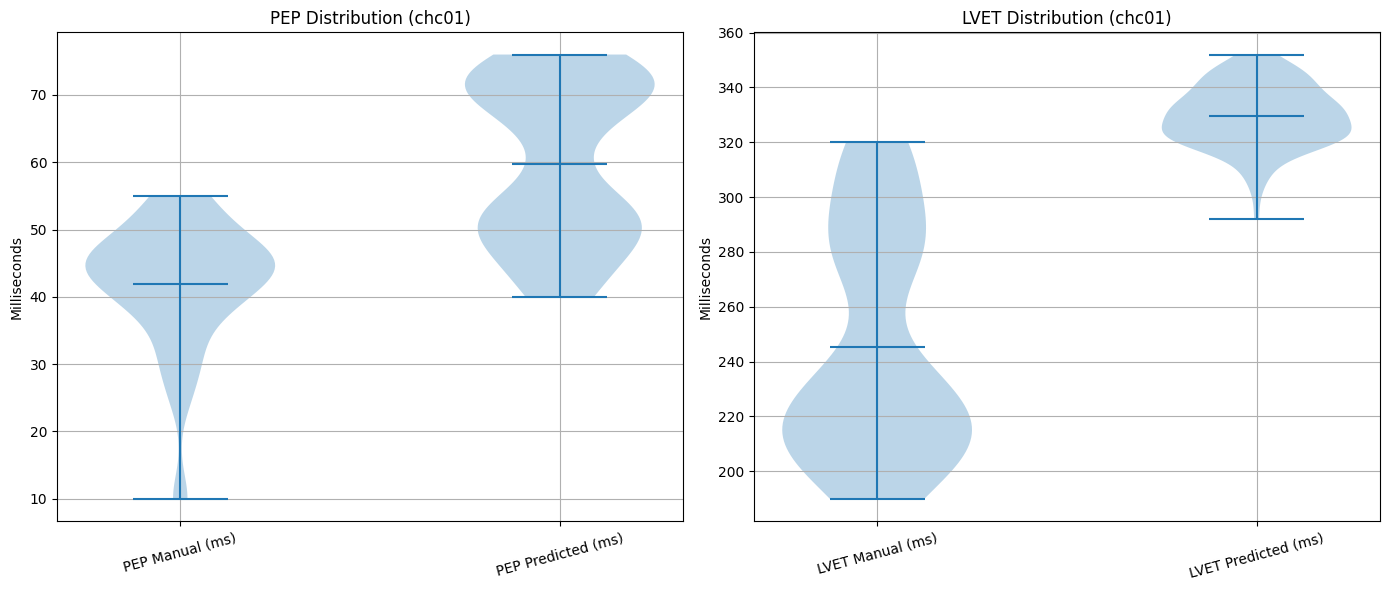

In [ ]:
import matplotlib.pyplot as plt

# Datos de PEP y LVET del conjunto chc01
pep_data = [pep_manual_all, pep_pred_all]
lvet_data = [lvet_manual_all, lvet_pred_all]

pep_labels = ['PEP Manual (ms)', 'PEP Predicted (ms)']
lvet_labels = ['LVET Manual (ms)', 'LVET Predicted (ms)']

# Configurar figura
plt.figure(figsize=(14, 6))

# PEP violin plot
plt.subplot(1, 2, 1)
plt.violinplot(pep_data, showmeans=True, showextrema=True)
plt.xticks(ticks=[1, 2], labels=pep_labels, rotation=15)
plt.ylabel("Milliseconds")
plt.title("PEP Distribution (chc01)")
plt.grid(True)

# LVET violin plot
plt.subplot(1, 2, 2)
plt.violinplot(lvet_data, showmeans=True, showextrema=True)
plt.xticks(ticks=[1, 2], labels=lvet_labels, rotation=15)
plt.ylabel("Milliseconds")
plt.title("LVET Distribution (chc01)")
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Inicializar resultados por sujeto
per_subject_results = {}

# Recorrer los archivos del subconjunto chc01
for filename in target_filenames:
    filename_key = filename + ".mat"
    if filename_key not in all_data or filename not in chc01_segment_map:
        continue

    try:
        data = all_data[filename_key]
        pep_echo = np.array(data["pep_ms"])
        lvet_echo = np.array(data["lvet_ms"])

        start_idx, end_idx = chc01_segment_map[filename]
        predicted_segments = predicted_labels_chc01[start_idx:end_idx]

        n_segments = min(len(predicted_segments), len(pep_echo), len(lvet_echo))

        pep_manual = []
        pep_pred = []
        lvet_manual = []
        lvet_pred = []

        for i in range(n_segments):
            b, x, o = predicted_segments[i]
            if not np.isnan(b):
                pep_time = ((b - offset) / fs) * 1000
                pep_pred.append(pep_time)
                pep_manual.append(pep_echo[i])
            if not np.isnan(b) and not np.isnan(x):
                lvet_time = ((x - b) / fs) * 1000
                lvet_pred.append(lvet_time)
                lvet_manual.append(lvet_echo[i])

        # Convertir a arrays
        pep_manual = np.array(pep_manual)
        pep_pred = np.array(pep_pred)
        lvet_manual = np.array(lvet_manual)
        lvet_pred = np.array(lvet_pred)

        # Alinear longitudes
        min_len_pep = min(len(pep_manual), len(pep_pred))
        min_len_lvet = min(len(lvet_manual), len(lvet_pred))

        pep_manual = pep_manual[:min_len_pep]
        pep_pred = pep_pred[:min_len_pep]
        lvet_manual = lvet_manual[:min_len_lvet]
        lvet_pred = lvet_pred[:min_len_lvet]

        # Calcular errores
        pep_mae = np.mean(np.abs(pep_pred - pep_manual)) if len(pep_manual) > 0 else np.nan
        lvet_mae = np.mean(np.abs(lvet_pred - lvet_manual)) if len(lvet_manual) > 0 else np.nan

        # Guardar resultados
        per_subject_results[filename] = {
            "pep_manual": pep_manual,
            "pep_pred": pep_pred,
            "pep_diff": pep_pred - pep_manual,
            "pep_mae": pep_mae,
            "lvet_manual": lvet_manual,
            "lvet_pred": lvet_pred,
            "lvet_diff": lvet_pred - lvet_manual,
            "lvet_mae": lvet_mae,
            "n_segments": len(pep_manual)
        }

    except Exception as e:
        print(f"Error in file {filename}: {e}")
        continue


<ipython-input-73-1ba169b08614>:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pep_maes, lvet_maes], patch_artist=True, labels=["PEP MAE", "LVET MAE"])


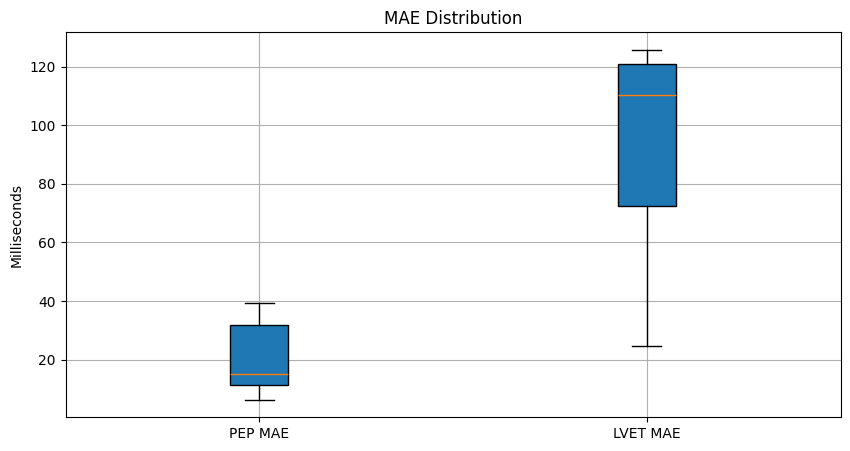

In [ ]:
pep_maes = [res["pep_mae"] for res in per_subject_results.values() if not np.isnan(res["pep_mae"])]
lvet_maes = [res["lvet_mae"] for res in per_subject_results.values() if not np.isnan(res["lvet_mae"])]

# Plot
plt.figure(figsize=(10, 5))
plt.boxplot([pep_maes, lvet_maes], patch_artist=True, labels=["PEP MAE", "LVET MAE"])
plt.title("MAE Distribution")
plt.ylabel("Milliseconds")
plt.grid(True)
plt.show()

In [ ]:
# --- PEP: % within 20ms and 40ms ---
pep_within_20 = np.nanmean(np.abs(pep_diff) <= 20) * 100
pep_within_40 = np.nanmean(np.abs(pep_diff) <= 40) * 100

# --- LVET: % within 60ms and 80ms ---
lvet_within_60 = np.nanmean(np.abs(lvet_diff) <= 60) * 100
lvet_within_80 = np.nanmean(np.abs(lvet_diff) <= 80) * 100

print(f"\n--- PEP ---")
print("Within ±20 ms: {:.2f}%".format(pep_within_20))
print("Within ±40 ms: {:.2f}%".format(pep_within_40))

print(f"\n--- LVET ---")
print("Within ±60 ms: {:.2f}%".format(lvet_within_60))
print("Within ±80 ms: {:.2f}%".format(lvet_within_80))


--- PEP ---
Within ±20 ms: 64.23%
Within ±40 ms: 90.51%

--- LVET ---
Within ±60 ms: 37.78%
Within ±80 ms: 37.78%


In [ ]:
import pandas as pd
import numpy as np

# Build a DataFrame
subject_df = pd.DataFrame([
    {
        "Subject": fname,
        "Num Segments": res["n_segments"],
        "PEP MAE (ms)": np.round(res["pep_mae"], 2),
        "LVET MAE (ms)": np.round(res["lvet_mae"], 2),
        "Mean PEP (manual)": np.round(np.mean(res["pep_manual"]), 2),
        "Mean LVET (manual)": np.round(np.mean(res["lvet_manual"]), 2)
    }
    for fname, res in per_subject_results.items()
    if not np.isnan(res["pep_mae"]) and not np.isnan(res["lvet_mae"])
])

# Display table
subject_df.sort_values("Subject").reset_index(drop=True)


,Subject,Num Segments,PEP MAE (ms),LVET MAE (ms),Mean PEP (manual),Mean LVET (manual)
0,59146238_s0000058,5,21.60,27.20,74.00,258.00
1,59146238_s0000079,3,24.00,34.33,76.67,268.33
2,59146238_s0000080,4,17.75,3.50,76.25,267.50
3,59146238_s0000081,4,26.75,39.00,76.25,267.50
4,59146238_s0000082,4,28.25,48.50,76.25,267.50
5,59146238_s0000083,4,22.75,16.00,76.25,267.50


In [ ]:
latex_table = subject_df.to_latex(
    index=False,
    longtable=True,
    caption="Per-subject Mean Absolute Error (MAE) for PEP and LVET prediction.",
    label="tab:subject_mae",
    column_format="lrrrrr",  # Adjust based on your columns
    float_format="%.2f"
)

# Save to file
with open("subject_mae_table.tex", "w") as f:
    f.write("\\chapter{Appendix}\n")
    f.write(latex_table)

# Validation with hemodynamic parameters CHC03

In [ ]:
import os
import scipy.io as sio
import numpy as np

# List of target filenames
target_filenames = [
    "59146238_s0000032",
    "59146238_s0000033",
    "59146238_s0000034",
    "59146238_s0000035",
    "59146238_s0000036",
    "59146238_s0000037",
    "59146238_s0000038",
    "59146238_s0000039",
    "59146238_s0000040",
    "59146238_s0000041"
]

# Base directory
base_dir = "/content/drive/MyDrive/TFG/Data_HeartCycle"

# Output lists
chc01_list = []
chc01_segment_map = {}  # filename → (start_idx, end_idx)
segment_index = 0

for filename in target_filenames:
    subject_id = filename.split("_")[0]
    file_path = os.path.join(base_dir, subject_id, filename + ".mat")

    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        continue

    try:
        data_hc = sio.loadmat(file_path)

        if 'measure' not in data_hc:
            print(f"No 'measure' key in {filename}")
            continue

        measures = data_hc['measure']

        # Extract signals
        icg = measures[1, 1]
        icg_time = icg['time'][0, 0].flatten()
        icg_data = icg['data'][0, 0].flatten()

        ecg = measures[0, 1]
        ecg_time = ecg['time'][0, 0].flatten()
        ecg_data = ecg['data'][0, 0].flatten()

        rpeaks = measures[2, 1]
        rpeaks_times = rpeaks['data'][0, 0].flatten()
        rpeaks_indices = np.array([np.argmin(np.abs(ecg_time - t)) for t in rpeaks_times])

        # Preprocess
        dz_dt_norm, ecg_norm = preprocess_signals(
            icg_data=icg_data,
            icg_time=icg_time,
            ecg_data=ecg_data,
            fs_icg=200,
            fs_ecg=200
        )

        # Segment and prepare input
        icg_segments = segment_icg(dz_dt_norm, rpeaks_indices, fs=200)
        ecg_segments = segment_icg(ecg_norm, rpeaks_indices, fs=200)

        icg_segments_up = upsample_segments(icg_segments, from_fs=200, to_fs=250)
        ecg_segments_up = upsample_segments(ecg_segments, from_fs=200, to_fs=250)

        X_input = prepare_icg_model_input(icg_segments_up, ecg_segments_up)

        # Track segment index range for this file
        num_segments = X_input.shape[0]
        chc01_segment_map[filename] = (segment_index, segment_index + num_segments)
        segment_index += num_segments

        chc01_list.append(X_input)

        print(f"{filename}: added {num_segments} segments")

    except Exception as e:
        print(f"Error loading {filename}: {e}")
        continue

# Final stack
chc01 = np.vstack(chc01_list) if chc01_list else np.empty((0, 200, 2))
print("Final chc01 shape:", chc01.shape)

# Split channels
icg_segments_chc01 = chc01[:, :, 0]
ecg_segments_chc01 = chc01[:, :, 1]

# Normalize per segment
X_input_chc01 = create_model_input(ecg_segments_chc01, icg_segments_chc01)

# Load trained model
predictor = load_model(model, compile=False)

# Predict
y_pred_chc01 = predictor.predict(X_input_chc01)  # shape: (n_segments, 200, 3)

# Extract predicted time indices for B, X, O
predicted_labels_chc01 = extract_predicted_points(y_pred_chc01)  # shape: (n_segments, 3)

# -----------------------------------------------------------
# Apply C-peak detection and filter invalid segments
# -----------------------------------------------------------
predicted_b_c_x_o_chc01 = detect_c_peak_after_r(icg_segments_chc01, predicted_labels_chc01, offset=offset, fs=fs)
corrected_chc01 = predicted_b_c_x_o_chc01.astype(float)

# Step 1: Remove early X points
for i in range(len(corrected_chc01)):
    x = corrected_chc01[i, 2]
    if x < offset + int(0.1 * fs):
        corrected_chc01[i, 2] = np.nan

# Step 2: Remove invalid B points
min_pep = int(0.03 * fs)
max_pep = int(0.13 * fs)
for i in range(len(corrected_chc01)):
    b, c = corrected_chc01[i, 0], corrected_chc01[i, 1]
    if np.isnan(b) or np.isnan(c) or b < offset or b >= c or not (min_pep <= b - offset <= max_pep):
        corrected_chc01[i, 0] = np.nan

# Step 3: Remove logical outliers
r_peaks_aligned = np.full(corrected_chc01.shape[0], offset)
outliers = detect_physiological_outliers(corrected_chc01, r_peaks_aligned)
valid_mask = ~(outliers['B'] | outliers['C'] | outliers['X'] | outliers['O'])
valid_indices = np.where(valid_mask)[0]
valid_index_map = {idx: i for i, idx in enumerate(valid_indices)}

# -----------------------------------------------------------
# Compute PEP and LVET only on valid segments
# -----------------------------------------------------------
pep_manual_all = []
pep_pred_all = []
lvet_manual_all = []
lvet_pred_all = []

for filename in target_filenames:
    filename_key = filename + ".mat"
    if filename_key not in all_data or filename not in chc01_segment_map:
        continue

    try:
        data = all_data[filename_key]
        pep_echo = np.array(data["pep_ms"])
        lvet_echo = np.array(data["lvet_ms"])

        start_idx, end_idx = chc01_segment_map[filename]
        file_indices = list(range(start_idx, end_idx))

        valid_in_file = [i for i, global_idx in enumerate(file_indices) if global_idx in valid_index_map]
        if not valid_in_file:
            continue

        corrected_indices = [valid_index_map[file_indices[i]] for i in valid_in_file]
        predicted_segments = corrected_chc01[valid_indices[corrected_indices]]

        pep_valid = pep_echo[valid_in_file]
        lvet_valid = lvet_echo[valid_in_file]

        pep_ms = []
        valid_pep_manual = []
        lvet_ms = []
        valid_lvet_manual = []

        for i, (b, c, x, o) in enumerate(predicted_segments):
            if not np.isnan(b):
                pep_time = ((b - offset) / fs) * 1000
                pep_ms.append(pep_time)
                valid_pep_manual.append(pep_valid[i])
            if not np.isnan(b) and not np.isnan(x):
                lvet_time = ((x - b) / fs) * 1000
                lvet_ms.append(lvet_time)
                valid_lvet_manual.append(lvet_valid[i])

        min_len_pep = min(len(valid_pep_manual), len(pep_ms))
        min_len_lvet = min(len(valid_lvet_manual), len(lvet_ms))

        pep_manual_all.extend(valid_pep_manual[:min_len_pep])
        pep_pred_all.extend(pep_ms[:min_len_pep])
        lvet_manual_all.extend(valid_lvet_manual[:min_len_lvet])
        lvet_pred_all.extend(lvet_ms[:min_len_lvet])

    except Exception as e:
        print(f"Error in file {filename}: {e}")
        continue

# Convert to arrays and round
pep_manual_all = np.array(pep_manual_all)
pep_pred_all = np.array(pep_pred_all)
lvet_manual_all = np.array(lvet_manual_all)
lvet_pred_all = np.array(lvet_pred_all)

pep_pred_all_round = np.round(pep_pred_all / 5) * 5
lvet_pred_all_round = np.round(lvet_pred_all / 5) * 5

pep_diff = pep_pred_all_round - pep_manual_all
lvet_diff = lvet_pred_all_round - lvet_manual_all

pep_mae = np.mean(np.abs(pep_diff)) if len(pep_diff) > 0 else np.nan
lvet_mae = np.mean(np.abs(lvet_diff)) if len(lvet_diff) > 0 else np.nan

# Results
print("\n--- PEP (chc01, filtered) ---")
print("PEP manual (ms):", pep_manual_all)
print("PEP predicted (ms):", pep_pred_all)
print("PEP predicted rounded (ms):", pep_pred_all_round)
print("PEP difference (ms):", pep_diff)
print(f"PEP MAE: {pep_mae:.2f} ms")

print("\n--- LVET (chc01, filtered) ---")
print("LVET manual (ms):", lvet_manual_all)
print("LVET predicted (ms):", lvet_pred_all)
print("LVET predicted rounded (ms):", lvet_pred_all_round)
print("LVET difference (ms):", lvet_diff)
print(f"LVET MAE: {lvet_mae:.2f} ms")


59146238_s0000032: added 9 segments
59146238_s0000033: added 9 segments
59146238_s0000034: added 9 segments
59146238_s0000035: added 10 segments
59146238_s0000036: added 9 segments
59146238_s0000037: added 9 segments
59146238_s0000038: added 9 segments
59146238_s0000039: added 9 segments
59146238_s0000040: added 10 segments
59146238_s0000041: added 9 segments
Final chc01 shape: (92, 200, 2)
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step

--- PEP (chc01, filtered) ---
PEP manual (ms): [10 45 45 45 40 40 45 45 45 10 45 45 45 40 40 45 45 45 10 45 45 45 40 40
 45 45 45 10 45 45 45 40 45 45 45 40 10 45 45 45 40 40 45 45 45 10 45 40
 45 45 40 40 40 45 10 45 40 45 45 40 40 40 45 10 45 40 45 45 40 40 40 45
 10 45 40 45 45 40 40 40 45 40 10 45 40 45 45 40 40 40 45]
PEP predicted (ms): [44. 40. 68. 72. 40. 40. 64. 72. 40. 36. 44. 40. 40. 44. 40. 44. 40. 44.
 72. 72. 68. 72. 44. 40. 40. 64. 68. 68. 40. 68. 40. 40. 40. 44. 40. 40.
 64. 40. 40. 40. 40. 44. 44. 44. 36. 72. 72. 40. 68. 68. 68. 72. 68. 64.
 68.

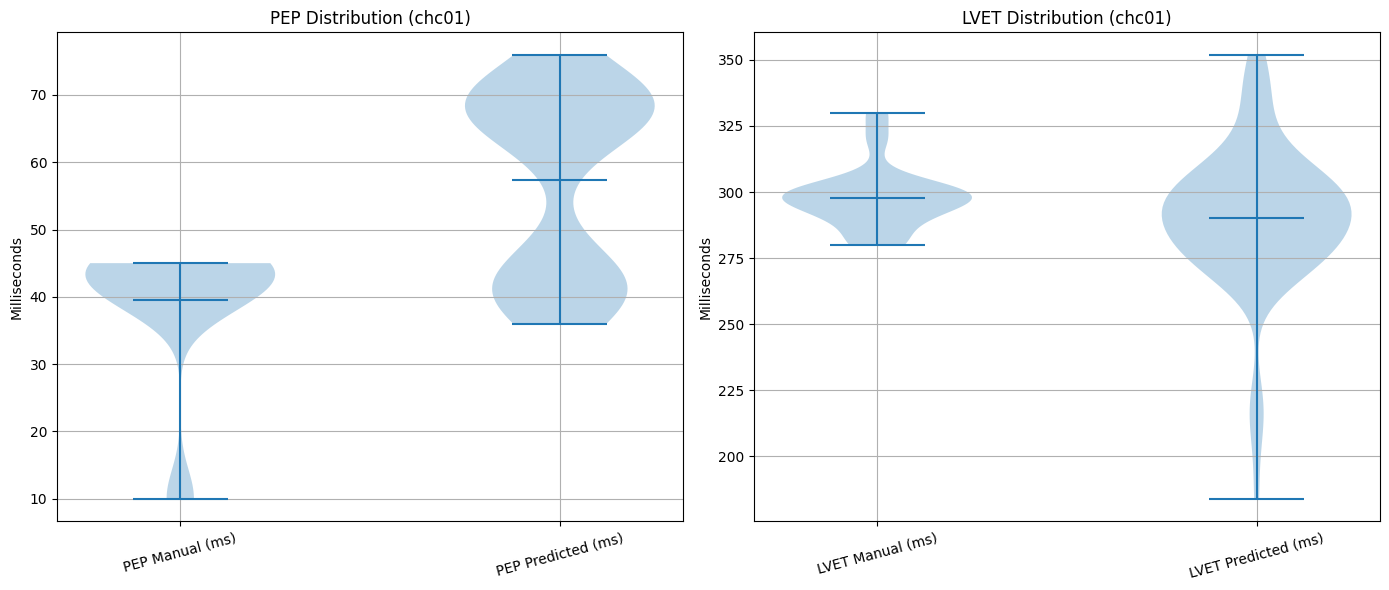

In [ ]:
import matplotlib.pyplot as plt

# Datos de PEP y LVET del conjunto chc01
pep_data = [pep_manual_all, pep_pred_all]
lvet_data = [lvet_manual_all, lvet_pred_all]

pep_labels = ['PEP Manual (ms)', 'PEP Predicted (ms)']
lvet_labels = ['LVET Manual (ms)', 'LVET Predicted (ms)']

# Configurar figura
plt.figure(figsize=(14, 6))

# PEP violin plot
plt.subplot(1, 2, 1)
plt.violinplot(pep_data, showmeans=True, showextrema=True)
plt.xticks(ticks=[1, 2], labels=pep_labels, rotation=15)
plt.ylabel("Milliseconds")
plt.title("PEP Distribution (chc01)")
plt.grid(True)

# LVET violin plot
plt.subplot(1, 2, 2)
plt.violinplot(lvet_data, showmeans=True, showextrema=True)
plt.xticks(ticks=[1, 2], labels=lvet_labels, rotation=15)
plt.ylabel("Milliseconds")
plt.title("LVET Distribution (chc01)")
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Inicializar resultados por sujeto
per_subject_results = {}

# Recorrer los archivos del subconjunto chc01
for filename in target_filenames:
    filename_key = filename + ".mat"
    if filename_key not in all_data or filename not in chc01_segment_map:
        continue

    try:
        data = all_data[filename_key]
        pep_echo = np.array(data["pep_ms"])
        lvet_echo = np.array(data["lvet_ms"])

        start_idx, end_idx = chc01_segment_map[filename]
        predicted_segments = predicted_labels_chc01[start_idx:end_idx]

        n_segments = min(len(predicted_segments), len(pep_echo), len(lvet_echo))

        pep_manual = []
        pep_pred = []
        lvet_manual = []
        lvet_pred = []

        for i in range(n_segments):
            b, x, o = predicted_segments[i]
            if not np.isnan(b):
                pep_time = ((b - offset) / fs) * 1000
                pep_pred.append(pep_time)
                pep_manual.append(pep_echo[i])
            if not np.isnan(b) and not np.isnan(x):
                lvet_time = ((x - b) / fs) * 1000
                lvet_pred.append(lvet_time)
                lvet_manual.append(lvet_echo[i])

        # Convertir a arrays
        pep_manual = np.array(pep_manual)
        pep_pred = np.array(pep_pred)
        lvet_manual = np.array(lvet_manual)
        lvet_pred = np.array(lvet_pred)

        # Alinear longitudes
        min_len_pep = min(len(pep_manual), len(pep_pred))
        min_len_lvet = min(len(lvet_manual), len(lvet_pred))

        pep_manual = pep_manual[:min_len_pep]
        pep_pred = pep_pred[:min_len_pep]
        lvet_manual = lvet_manual[:min_len_lvet]
        lvet_pred = lvet_pred[:min_len_lvet]

        # Calcular errores
        pep_mae = np.mean(np.abs(pep_pred - pep_manual)) if len(pep_manual) > 0 else np.nan
        lvet_mae = np.mean(np.abs(lvet_pred - lvet_manual)) if len(lvet_manual) > 0 else np.nan

        # Guardar resultados
        per_subject_results[filename] = {
            "pep_manual": pep_manual,
            "pep_pred": pep_pred,
            "pep_diff": pep_pred - pep_manual,
            "pep_mae": pep_mae,
            "lvet_manual": lvet_manual,
            "lvet_pred": lvet_pred,
            "lvet_diff": lvet_pred - lvet_manual,
            "lvet_mae": lvet_mae,
            "n_segments": len(pep_manual)
        }

    except Exception as e:
        print(f"Error in file {filename}: {e}")
        continue


<ipython-input-83-1ba169b08614>:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pep_maes, lvet_maes], patch_artist=True, labels=["PEP MAE", "LVET MAE"])


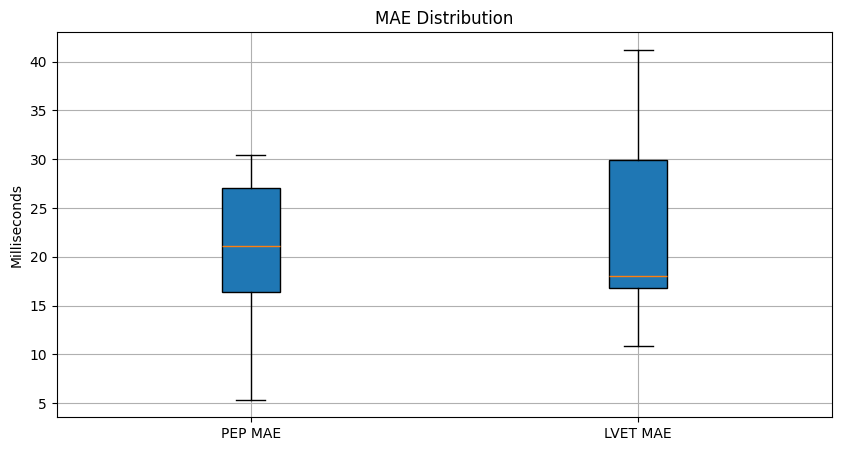

In [ ]:
pep_maes = [res["pep_mae"] for res in per_subject_results.values() if not np.isnan(res["pep_mae"])]
lvet_maes = [res["lvet_mae"] for res in per_subject_results.values() if not np.isnan(res["lvet_mae"])]

# Plot
plt.figure(figsize=(10, 5))
plt.boxplot([pep_maes, lvet_maes], patch_artist=True, labels=["PEP MAE", "LVET MAE"])
plt.title("MAE Distribution")
plt.ylabel("Milliseconds")
plt.grid(True)
plt.show()

In [ ]:
# --- PEP: % within 20ms and 40ms ---
pep_within_20 = np.nanmean(np.abs(pep_diff) <= 20) * 100
pep_within_40 = np.nanmean(np.abs(pep_diff) <= 40) * 100

# --- LVET: % within 60ms and 80ms ---
lvet_within_60 = np.nanmean(np.abs(lvet_diff) <= 60) * 100
lvet_within_80 = np.nanmean(np.abs(lvet_diff) <= 80) * 100

print(f"\n--- PEP ---")
print("Within ±20 ms: {:.2f}%".format(pep_within_20))
print("Within ±40 ms: {:.2f}%".format(pep_within_40))

print(f"\n--- LVET ---")
print("Within ±60 ms: {:.2f}%".format(lvet_within_60))
print("Within ±80 ms: {:.2f}%".format(lvet_within_80))


--- PEP ---
Within ±20 ms: 42.86%
Within ±40 ms: 92.31%

--- LVET ---
Within ±60 ms: 93.41%
Within ±80 ms: 96.70%


In [ ]:
import pandas as pd
import numpy as np

# Build a DataFrame
subject_df = pd.DataFrame([
    {
        "Subject": fname,
        "Num Segments": res["n_segments"],
        "PEP MAE (ms)": np.round(res["pep_mae"], 2),
        "LVET MAE (ms)": np.round(res["lvet_mae"], 2),
        "Mean PEP (manual)": np.round(np.mean(res["pep_manual"]), 2),
        "Mean LVET (manual)": np.round(np.mean(res["lvet_manual"]), 2)
    }
    for fname, res in per_subject_results.items()
    if not np.isnan(res["pep_mae"]) and not np.isnan(res["lvet_mae"])
])

# Display table
subject_df.sort_values("Subject").reset_index(drop=True)


,Subject,Num Segments,PEP MAE (ms),LVET MAE (ms),Mean PEP (manual),Mean LVET (manual)
0,59146238_s0000058,5,21.60,27.20,74.00,258.00
1,59146238_s0000079,3,24.00,34.33,76.67,268.33
2,59146238_s0000080,4,17.75,3.50,76.25,267.50
3,59146238_s0000081,4,26.75,39.00,76.25,267.50
4,59146238_s0000082,4,28.25,48.50,76.25,267.50
5,59146238_s0000083,4,22.75,16.00,76.25,267.50


In [ ]:
latex_table = subject_df.to_latex(
    index=False,
    longtable=True,
    caption="Per-subject Mean Absolute Error (MAE) for PEP and LVET prediction.",
    label="tab:subject_mae",
    column_format="lrrrrr",  # Adjust based on your columns
    float_format="%.2f"
)

# Save to file
with open("subject_mae_table.tex", "w") as f:
    f.write("\\chapter{Appendix}\n")
    f.write(latex_table)

# Validation with hemodynamic parameters CHC04

In [ ]:
import os
import scipy.io as sio
import numpy as np

# List of target filenames
target_filenames = [
    "59146238_s0000021",
    "59146238_s0000022",
    "59146238_s0000023",
    "59146238_s0000024",
    "59146238_s0000025",
    "59146238_s0000026",
    "59146238_s0000027",
    "59146238_s0000028",
    "59146238_s0000029",
    "59146238_s0000030",
    "59146238_s0000031"
]

# Base directory
base_dir = "/content/drive/MyDrive/TFG/Data_HeartCycle"

# Output lists
chc01_list = []
chc01_segment_map = {}  # filename → (start_idx, end_idx)
segment_index = 0

for filename in target_filenames:
    subject_id = filename.split("_")[0]
    file_path = os.path.join(base_dir, subject_id, filename + ".mat")

    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        continue

    try:
        data_hc = sio.loadmat(file_path)

        if 'measure' not in data_hc:
            print(f"No 'measure' key in {filename}")
            continue

        measures = data_hc['measure']

        # Extract signals
        icg = measures[1, 1]
        icg_time = icg['time'][0, 0].flatten()
        icg_data = icg['data'][0, 0].flatten()

        ecg = measures[0, 1]
        ecg_time = ecg['time'][0, 0].flatten()
        ecg_data = ecg['data'][0, 0].flatten()

        rpeaks = measures[2, 1]
        rpeaks_times = rpeaks['data'][0, 0].flatten()
        rpeaks_indices = np.array([np.argmin(np.abs(ecg_time - t)) for t in rpeaks_times])

        # Preprocess
        dz_dt_norm, ecg_norm = preprocess_signals(
            icg_data=icg_data,
            icg_time=icg_time,
            ecg_data=ecg_data,
            fs_icg=200,
            fs_ecg=200
        )

        # Segment and prepare input
        icg_segments = segment_icg(dz_dt_norm, rpeaks_indices, fs=200)
        ecg_segments = segment_icg(ecg_norm, rpeaks_indices, fs=200)

        icg_segments_up = upsample_segments(icg_segments, from_fs=200, to_fs=250)
        ecg_segments_up = upsample_segments(ecg_segments, from_fs=200, to_fs=250)

        X_input = prepare_icg_model_input(icg_segments_up, ecg_segments_up)

        # Track segment index range for this file
        num_segments = X_input.shape[0]
        chc01_segment_map[filename] = (segment_index, segment_index + num_segments)
        segment_index += num_segments

        chc01_list.append(X_input)

        print(f"{filename}: added {num_segments} segments")

    except Exception as e:
        print(f"Error loading {filename}: {e}")
        continue

# Final stack
chc01 = np.vstack(chc01_list) if chc01_list else np.empty((0, 200, 2))
print("Final chc01 shape:", chc01.shape)

# Split channels
icg_segments_chc01 = chc01[:, :, 0]
ecg_segments_chc01 = chc01[:, :, 1]

# Normalize per segment
X_input_chc01 = create_model_input(ecg_segments_chc01, icg_segments_chc01)

# Load trained model
predictor = load_model(model, compile=False)

# Predict
y_pred_chc01 = predictor.predict(X_input_chc01)  # shape: (n_segments, 200, 3)

# Extract predicted time indices for B, X, O
predicted_labels_chc01 = extract_predicted_points(y_pred_chc01)  # shape: (n_segments, 3)

# -----------------------------------------------------------
# Apply C-peak detection and filter invalid segments
# -----------------------------------------------------------
predicted_b_c_x_o_chc01 = detect_c_peak_after_r(icg_segments_chc01, predicted_labels_chc01, offset=offset, fs=fs)
corrected_chc01 = predicted_b_c_x_o_chc01.astype(float)

# Step 1: Remove early X points
for i in range(len(corrected_chc01)):
    x = corrected_chc01[i, 2]
    if x < offset + int(0.1 * fs):
        corrected_chc01[i, 2] = np.nan

# Step 2: Remove invalid B points
min_pep = int(0.03 * fs)
max_pep = int(0.13 * fs)
for i in range(len(corrected_chc01)):
    b, c = corrected_chc01[i, 0], corrected_chc01[i, 1]
    if np.isnan(b) or np.isnan(c) or b < offset or b >= c or not (min_pep <= b - offset <= max_pep):
        corrected_chc01[i, 0] = np.nan

# Step 3: Remove logical outliers
r_peaks_aligned = np.full(corrected_chc01.shape[0], offset)
outliers = detect_physiological_outliers(corrected_chc01, r_peaks_aligned)
valid_mask = ~(outliers['B'] | outliers['C'] | outliers['X'] | outliers['O'])
valid_indices = np.where(valid_mask)[0]
valid_index_map = {idx: i for i, idx in enumerate(valid_indices)}

# -----------------------------------------------------------
# Compute PEP and LVET only on valid segments
# -----------------------------------------------------------
pep_manual_all = []
pep_pred_all = []
lvet_manual_all = []
lvet_pred_all = []

for filename in target_filenames:
    filename_key = filename + ".mat"
    if filename_key not in all_data or filename not in chc01_segment_map:
        continue

    try:
        data = all_data[filename_key]
        pep_echo = np.array(data["pep_ms"])
        lvet_echo = np.array(data["lvet_ms"])

        start_idx, end_idx = chc01_segment_map[filename]
        file_indices = list(range(start_idx, end_idx))

        valid_in_file = [i for i, global_idx in enumerate(file_indices) if global_idx in valid_index_map]
        if not valid_in_file:
            continue

        corrected_indices = [valid_index_map[file_indices[i]] for i in valid_in_file]
        predicted_segments = corrected_chc01[valid_indices[corrected_indices]]

        pep_valid = pep_echo[valid_in_file]
        lvet_valid = lvet_echo[valid_in_file]

        pep_ms = []
        valid_pep_manual = []
        lvet_ms = []
        valid_lvet_manual = []

        for i, (b, c, x, o) in enumerate(predicted_segments):
            if not np.isnan(b):
                pep_time = ((b - offset) / fs) * 1000
                pep_ms.append(pep_time)
                valid_pep_manual.append(pep_valid[i])
            if not np.isnan(b) and not np.isnan(x):
                lvet_time = ((x - b) / fs) * 1000
                lvet_ms.append(lvet_time)
                valid_lvet_manual.append(lvet_valid[i])

        min_len_pep = min(len(valid_pep_manual), len(pep_ms))
        min_len_lvet = min(len(valid_lvet_manual), len(lvet_ms))

        pep_manual_all.extend(valid_pep_manual[:min_len_pep])
        pep_pred_all.extend(pep_ms[:min_len_pep])
        lvet_manual_all.extend(valid_lvet_manual[:min_len_lvet])
        lvet_pred_all.extend(lvet_ms[:min_len_lvet])

    except Exception as e:
        print(f"Error in file {filename}: {e}")
        continue

# Convert to arrays and round
pep_manual_all = np.array(pep_manual_all)
pep_pred_all = np.array(pep_pred_all)
lvet_manual_all = np.array(lvet_manual_all)
lvet_pred_all = np.array(lvet_pred_all)

pep_pred_all_round = np.round(pep_pred_all / 5) * 5
lvet_pred_all_round = np.round(lvet_pred_all / 5) * 5

pep_diff = pep_pred_all_round - pep_manual_all
lvet_diff = lvet_pred_all_round - lvet_manual_all

pep_mae = np.mean(np.abs(pep_diff)) if len(pep_diff) > 0 else np.nan
lvet_mae = np.mean(np.abs(lvet_diff)) if len(lvet_diff) > 0 else np.nan

# Results
print("\n--- PEP (chc01, filtered) ---")
print("PEP manual (ms):", pep_manual_all)
print("PEP predicted (ms):", pep_pred_all)
print("PEP predicted rounded (ms):", pep_pred_all_round)
print("PEP difference (ms):", pep_diff)
print(f"PEP MAE: {pep_mae:.2f} ms")

print("\n--- LVET (chc01, filtered) ---")
print("LVET manual (ms):", lvet_manual_all)
print("LVET predicted (ms):", lvet_pred_all)
print("LVET predicted rounded (ms):", lvet_pred_all_round)
print("LVET difference (ms):", lvet_diff)
print(f"LVET MAE: {lvet_mae:.2f} ms")


59146238_s0000021: added 8 segments
59146238_s0000022: added 8 segments
59146238_s0000023: added 9 segments
59146238_s0000024: added 9 segments
59146238_s0000025: added 9 segments
59146238_s0000026: added 9 segments
59146238_s0000027: added 9 segments
59146238_s0000028: added 10 segments
59146238_s0000029: added 10 segments
59146238_s0000030: added 10 segments
59146238_s0000031: added 10 segments
Final chc01 shape: (101, 200, 2)
4/4 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step

--- PEP (chc01, filtered) ---
PEP manual (ms): [ 10  45  45  45  95  45  45  45  10  45  45  45  95  45  45  45  10  45
  45  95  45  45  45  45  10  45  45  45  95  45  45  45  10  45  45  45
  95  45  45  45  45 105  45  45  45  45  45  45  45  45 105  45  45  45
  45  45  45  45  45 105  45  45  45  45  45  45  45 105  45  45  45  45
  45  45  45  45  45 105  45  45  45  45  45  45  45  45  45  45  45  45
  45  45  45]
PEP predicted (ms): [76. 76. 76. 80. 80. 76. 76. 68. 76. 72. 72. 72. 72. 72. 72. 76. 76. 76.
 72. 76. 7

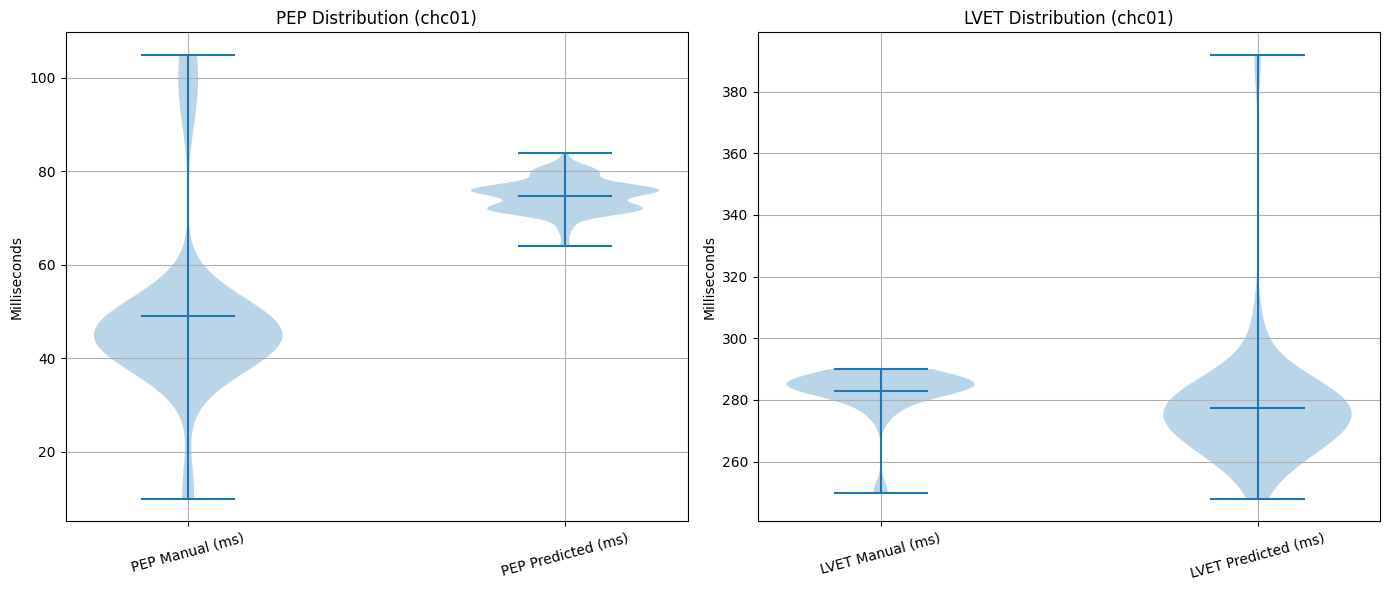

In [ ]:
import matplotlib.pyplot as plt

# Datos de PEP y LVET del conjunto chc01
pep_data = [pep_manual_all, pep_pred_all]
lvet_data = [lvet_manual_all, lvet_pred_all]

pep_labels = ['PEP Manual (ms)', 'PEP Predicted (ms)']
lvet_labels = ['LVET Manual (ms)', 'LVET Predicted (ms)']

# Configurar figura
plt.figure(figsize=(14, 6))

# PEP violin plot
plt.subplot(1, 2, 1)
plt.violinplot(pep_data, showmeans=True, showextrema=True)
plt.xticks(ticks=[1, 2], labels=pep_labels, rotation=15)
plt.ylabel("Milliseconds")
plt.title("PEP Distribution (chc01)")
plt.grid(True)

# LVET violin plot
plt.subplot(1, 2, 2)
plt.violinplot(lvet_data, showmeans=True, showextrema=True)
plt.xticks(ticks=[1, 2], labels=lvet_labels, rotation=15)
plt.ylabel("Milliseconds")
plt.title("LVET Distribution (chc01)")
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Inicializar resultados por sujeto
per_subject_results = {}

# Recorrer los archivos del subconjunto chc01
for filename in target_filenames:
    filename_key = filename + ".mat"
    if filename_key not in all_data or filename not in chc01_segment_map:
        continue

    try:
        data = all_data[filename_key]
        pep_echo = np.array(data["pep_ms"])
        lvet_echo = np.array(data["lvet_ms"])

        start_idx, end_idx = chc01_segment_map[filename]
        predicted_segments = predicted_labels_chc01[start_idx:end_idx]

        n_segments = min(len(predicted_segments), len(pep_echo), len(lvet_echo))

        pep_manual = []
        pep_pred = []
        lvet_manual = []
        lvet_pred = []

        for i in range(n_segments):
            b, x, o = predicted_segments[i]
            if not np.isnan(b):
                pep_time = ((b - offset) / fs) * 1000
                pep_pred.append(pep_time)
                pep_manual.append(pep_echo[i])
            if not np.isnan(b) and not np.isnan(x):
                lvet_time = ((x - b) / fs) * 1000
                lvet_pred.append(lvet_time)
                lvet_manual.append(lvet_echo[i])

        # Convertir a arrays
        pep_manual = np.array(pep_manual)
        pep_pred = np.array(pep_pred)
        lvet_manual = np.array(lvet_manual)
        lvet_pred = np.array(lvet_pred)

        # Alinear longitudes
        min_len_pep = min(len(pep_manual), len(pep_pred))
        min_len_lvet = min(len(lvet_manual), len(lvet_pred))

        pep_manual = pep_manual[:min_len_pep]
        pep_pred = pep_pred[:min_len_pep]
        lvet_manual = lvet_manual[:min_len_lvet]
        lvet_pred = lvet_pred[:min_len_lvet]

        # Calcular errores
        pep_mae = np.mean(np.abs(pep_pred - pep_manual)) if len(pep_manual) > 0 else np.nan
        lvet_mae = np.mean(np.abs(lvet_pred - lvet_manual)) if len(lvet_manual) > 0 else np.nan

        # Guardar resultados
        per_subject_results[filename] = {
            "pep_manual": pep_manual,
            "pep_pred": pep_pred,
            "pep_diff": pep_pred - pep_manual,
            "pep_mae": pep_mae,
            "lvet_manual": lvet_manual,
            "lvet_pred": lvet_pred,
            "lvet_diff": lvet_pred - lvet_manual,
            "lvet_mae": lvet_mae,
            "n_segments": len(pep_manual)
        }

    except Exception as e:
        print(f"Error in file {filename}: {e}")
        continue


<ipython-input-88-1ba169b08614>:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pep_maes, lvet_maes], patch_artist=True, labels=["PEP MAE", "LVET MAE"])


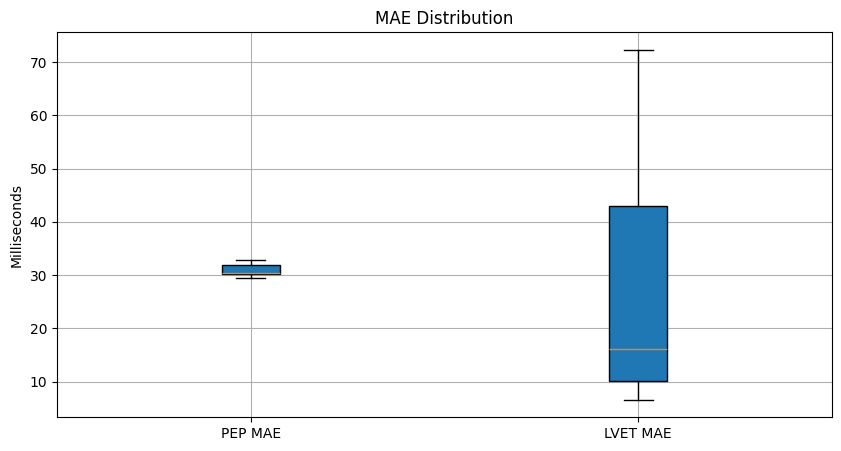

In [ ]:
pep_maes = [res["pep_mae"] for res in per_subject_results.values() if not np.isnan(res["pep_mae"])]
lvet_maes = [res["lvet_mae"] for res in per_subject_results.values() if not np.isnan(res["lvet_mae"])]

# Plot
plt.figure(figsize=(10, 5))
plt.boxplot([pep_maes, lvet_maes], patch_artist=True, labels=["PEP MAE", "LVET MAE"])
plt.title("MAE Distribution")
plt.ylabel("Milliseconds")
plt.grid(True)
plt.show()

In [ ]:
# --- PEP: % within 20ms and 40ms ---
pep_within_20 = np.nanmean(np.abs(pep_diff) <= 20) * 100
pep_within_40 = np.nanmean(np.abs(pep_diff) <= 40) * 100

# --- LVET: % within 60ms and 80ms ---
lvet_within_60 = np.nanmean(np.abs(lvet_diff) <= 60) * 100
lvet_within_80 = np.nanmean(np.abs(lvet_diff) <= 80) * 100

print(f"\n--- PEP ---")
print("Within ±20 ms: {:.2f}%".format(pep_within_20))
print("Within ±40 ms: {:.2f}%".format(pep_within_40))

print(f"\n--- LVET ---")
print("Within ±60 ms: {:.2f}%".format(lvet_within_60))
print("Within ±80 ms: {:.2f}%".format(lvet_within_80))


--- PEP ---
Within ±20 ms: 4.30%
Within ±40 ms: 94.62%

--- LVET ---
Within ±60 ms: 97.85%
Within ±80 ms: 97.85%


In [ ]:
import pandas as pd
import numpy as np

# Build a DataFrame
subject_df = pd.DataFrame([
    {
        "Subject": fname,
        "Num Segments": res["n_segments"],
        "PEP MAE (ms)": np.round(res["pep_mae"], 2),
        "LVET MAE (ms)": np.round(res["lvet_mae"], 2),
        "Mean PEP (manual)": np.round(np.mean(res["pep_manual"]), 2),
        "Mean LVET (manual)": np.round(np.mean(res["lvet_manual"]), 2)
    }
    for fname, res in per_subject_results.items()
    if not np.isnan(res["pep_mae"]) and not np.isnan(res["lvet_mae"])
])

# Display table
subject_df.sort_values("Subject").reset_index(drop=True)


,Subject,Num Segments,PEP MAE (ms),LVET MAE (ms),Mean PEP (manual),Mean LVET (manual)
0,59146238_s0000058,5,21.60,27.20,74.00,258.00
1,59146238_s0000079,3,24.00,34.33,76.67,268.33
2,59146238_s0000080,4,17.75,3.50,76.25,267.50
3,59146238_s0000081,4,26.75,39.00,76.25,267.50
4,59146238_s0000082,4,28.25,48.50,76.25,267.50
5,59146238_s0000083,4,22.75,16.00,76.25,267.50


In [ ]:
latex_table = subject_df.to_latex(
    index=False,
    longtable=True,
    caption="Per-subject Mean Absolute Error (MAE) for PEP and LVET prediction.",
    label="tab:subject_mae",
    column_format="lrrrrr",  # Adjust based on your columns
    float_format="%.2f"
)

# Save to file
with open("subject_mae_table.tex", "w") as f:
    f.write("\\chapter{Appendix}\n")
    f.write(latex_table)

# Validation with hemodynamic parameters CHC05

In [ ]:
import os
import scipy.io as sio
import numpy as np

# List of target filenames
target_filenames = [
    "59146238_s0000021",
    "59146238_s0000022",
    "59146238_s0000023",
    "59146238_s0000024",
    "59146238_s0000025",
    "59146238_s0000026",
    "59146238_s0000027",
    "59146238_s0000028",
    "59146238_s0000029",
    "59146238_s0000030",
    "59146238_s0000031"
]

# Base directory
base_dir = "/content/drive/MyDrive/TFG/Data_HeartCycle"

# Output lists
chc01_list = []
chc01_segment_map = {}  # filename → (start_idx, end_idx)
segment_index = 0

for filename in target_filenames:
    subject_id = filename.split("_")[0]
    file_path = os.path.join(base_dir, subject_id, filename + ".mat")

    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        continue

    try:
        data_hc = sio.loadmat(file_path)

        if 'measure' not in data_hc:
            print(f"No 'measure' key in {filename}")
            continue

        measures = data_hc['measure']

        # Extract signals
        icg = measures[1, 1]
        icg_time = icg['time'][0, 0].flatten()
        icg_data = icg['data'][0, 0].flatten()

        ecg = measures[0, 1]
        ecg_time = ecg['time'][0, 0].flatten()
        ecg_data = ecg['data'][0, 0].flatten()

        rpeaks = measures[2, 1]
        rpeaks_times = rpeaks['data'][0, 0].flatten()
        rpeaks_indices = np.array([np.argmin(np.abs(ecg_time - t)) for t in rpeaks_times])

        # Preprocess
        dz_dt_norm, ecg_norm = preprocess_signals(
            icg_data=icg_data,
            icg_time=icg_time,
            ecg_data=ecg_data,
            fs_icg=200,
            fs_ecg=200
        )

        # Segment and prepare input
        icg_segments = segment_icg(dz_dt_norm, rpeaks_indices, fs=200)
        ecg_segments = segment_icg(ecg_norm, rpeaks_indices, fs=200)

        icg_segments_up = upsample_segments(icg_segments, from_fs=200, to_fs=250)
        ecg_segments_up = upsample_segments(ecg_segments, from_fs=200, to_fs=250)

        X_input = prepare_icg_model_input(icg_segments_up, ecg_segments_up)

        # Track segment index range for this file
        num_segments = X_input.shape[0]
        chc01_segment_map[filename] = (segment_index, segment_index + num_segments)
        segment_index += num_segments

        chc01_list.append(X_input)

        print(f"{filename}: added {num_segments} segments")

    except Exception as e:
        print(f"Error loading {filename}: {e}")
        continue

# Final stack
chc01 = np.vstack(chc01_list) if chc01_list else np.empty((0, 200, 2))
print("Final chc01 shape:", chc01.shape)

# Split channels
icg_segments_chc01 = chc01[:, :, 0]
ecg_segments_chc01 = chc01[:, :, 1]

# Normalize per segment
X_input_chc01 = create_model_input(ecg_segments_chc01, icg_segments_chc01)

# Load trained model
predictor = load_model(model, compile=False)

# Predict
y_pred_chc01 = predictor.predict(X_input_chc01)  # shape: (n_segments, 200, 3)

# Extract predicted time indices for B, X, O
predicted_labels_chc01 = extract_predicted_points(y_pred_chc01)  # shape: (n_segments, 3)

# -----------------------------------------------------------
# Apply C-peak detection and filter invalid segments
# -----------------------------------------------------------
predicted_b_c_x_o_chc01 = detect_c_peak_after_r(icg_segments_chc01, predicted_labels_chc01, offset=offset, fs=fs)
corrected_chc01 = predicted_b_c_x_o_chc01.astype(float)

# Step 1: Remove early X points
for i in range(len(corrected_chc01)):
    x = corrected_chc01[i, 2]
    if x < offset + int(0.1 * fs):
        corrected_chc01[i, 2] = np.nan

# Step 2: Remove invalid B points
min_pep = int(0.03 * fs)
max_pep = int(0.13 * fs)
for i in range(len(corrected_chc01)):
    b, c = corrected_chc01[i, 0], corrected_chc01[i, 1]
    if np.isnan(b) or np.isnan(c) or b < offset or b >= c or not (min_pep <= b - offset <= max_pep):
        corrected_chc01[i, 0] = np.nan

# Step 3: Remove logical outliers
r_peaks_aligned = np.full(corrected_chc01.shape[0], offset)
outliers = detect_physiological_outliers(corrected_chc01, r_peaks_aligned)
valid_mask = ~(outliers['B'] | outliers['C'] | outliers['X'] | outliers['O'])
valid_indices = np.where(valid_mask)[0]
valid_index_map = {idx: i for i, idx in enumerate(valid_indices)}

# -----------------------------------------------------------
# Compute PEP and LVET only on valid segments
# -----------------------------------------------------------
pep_manual_all = []
pep_pred_all = []
lvet_manual_all = []
lvet_pred_all = []

for filename in target_filenames:
    filename_key = filename + ".mat"
    if filename_key not in all_data or filename not in chc01_segment_map:
        continue

    try:
        data = all_data[filename_key]
        pep_echo = np.array(data["pep_ms"])
        lvet_echo = np.array(data["lvet_ms"])

        start_idx, end_idx = chc01_segment_map[filename]
        file_indices = list(range(start_idx, end_idx))

        valid_in_file = [i for i, global_idx in enumerate(file_indices) if global_idx in valid_index_map]
        if not valid_in_file:
            continue

        corrected_indices = [valid_index_map[file_indices[i]] for i in valid_in_file]
        predicted_segments = corrected_chc01[valid_indices[corrected_indices]]

        pep_valid = pep_echo[valid_in_file]
        lvet_valid = lvet_echo[valid_in_file]

        pep_ms = []
        valid_pep_manual = []
        lvet_ms = []
        valid_lvet_manual = []

        for i, (b, c, x, o) in enumerate(predicted_segments):
            if not np.isnan(b):
                pep_time = ((b - offset) / fs) * 1000
                pep_ms.append(pep_time)
                valid_pep_manual.append(pep_valid[i])
            if not np.isnan(b) and not np.isnan(x):
                lvet_time = ((x - b) / fs) * 1000
                lvet_ms.append(lvet_time)
                valid_lvet_manual.append(lvet_valid[i])

        min_len_pep = min(len(valid_pep_manual), len(pep_ms))
        min_len_lvet = min(len(valid_lvet_manual), len(lvet_ms))

        pep_manual_all.extend(valid_pep_manual[:min_len_pep])
        pep_pred_all.extend(pep_ms[:min_len_pep])
        lvet_manual_all.extend(valid_lvet_manual[:min_len_lvet])
        lvet_pred_all.extend(lvet_ms[:min_len_lvet])

    except Exception as e:
        print(f"Error in file {filename}: {e}")
        continue

# Convert to arrays and round
pep_manual_all = np.array(pep_manual_all)
pep_pred_all = np.array(pep_pred_all)
lvet_manual_all = np.array(lvet_manual_all)
lvet_pred_all = np.array(lvet_pred_all)

pep_pred_all_round = np.round(pep_pred_all / 5) * 5
lvet_pred_all_round = np.round(lvet_pred_all / 5) * 5

pep_diff = pep_pred_all_round - pep_manual_all
lvet_diff = lvet_pred_all_round - lvet_manual_all

pep_mae = np.mean(np.abs(pep_diff)) if len(pep_diff) > 0 else np.nan
lvet_mae = np.mean(np.abs(lvet_diff)) if len(lvet_diff) > 0 else np.nan

# Results
print("\n--- PEP (chc01, filtered) ---")
print("PEP manual (ms):", pep_manual_all)
print("PEP predicted (ms):", pep_pred_all)
print("PEP predicted rounded (ms):", pep_pred_all_round)
print("PEP difference (ms):", pep_diff)
print(f"PEP MAE: {pep_mae:.2f} ms")

print("\n--- LVET (chc01, filtered) ---")
print("LVET manual (ms):", lvet_manual_all)
print("LVET predicted (ms):", lvet_pred_all)
print("LVET predicted rounded (ms):", lvet_pred_all_round)
print("LVET difference (ms):", lvet_diff)
print(f"LVET MAE: {lvet_mae:.2f} ms")


59146238_s0000021: added 8 segments
59146238_s0000022: added 8 segments
59146238_s0000023: added 9 segments
59146238_s0000024: added 9 segments
59146238_s0000025: added 9 segments
59146238_s0000026: added 9 segments
59146238_s0000027: added 9 segments
59146238_s0000028: added 10 segments
59146238_s0000029: added 10 segments
59146238_s0000030: added 10 segments
59146238_s0000031: added 10 segments
Final chc01 shape: (101, 200, 2)
4/4 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step

--- PEP (chc01, filtered) ---
PEP manual (ms): [ 10  45  45  45  95  45  45  45  10  45  45  45  95  45  45  45  10  45
  45  95  45  45  45  45  10  45  45  45  95  45  45  45  10  45  45  45
  95  45  45  45  45 105  45  45  45  45  45  45  45  45 105  45  45  45
  45  45  45  45  45 105  45  45  45  45  45  45  45 105  45  45  45  45
  45  45  45  45  45 105  45  45  45  45  45  45  45  45  45  45  45  45
  45  45  45]
PEP predicted (ms): [76. 76. 76. 80. 80. 76. 76. 68. 76. 72. 72. 72. 72. 72. 72. 76. 76. 76.
 72. 76. 7

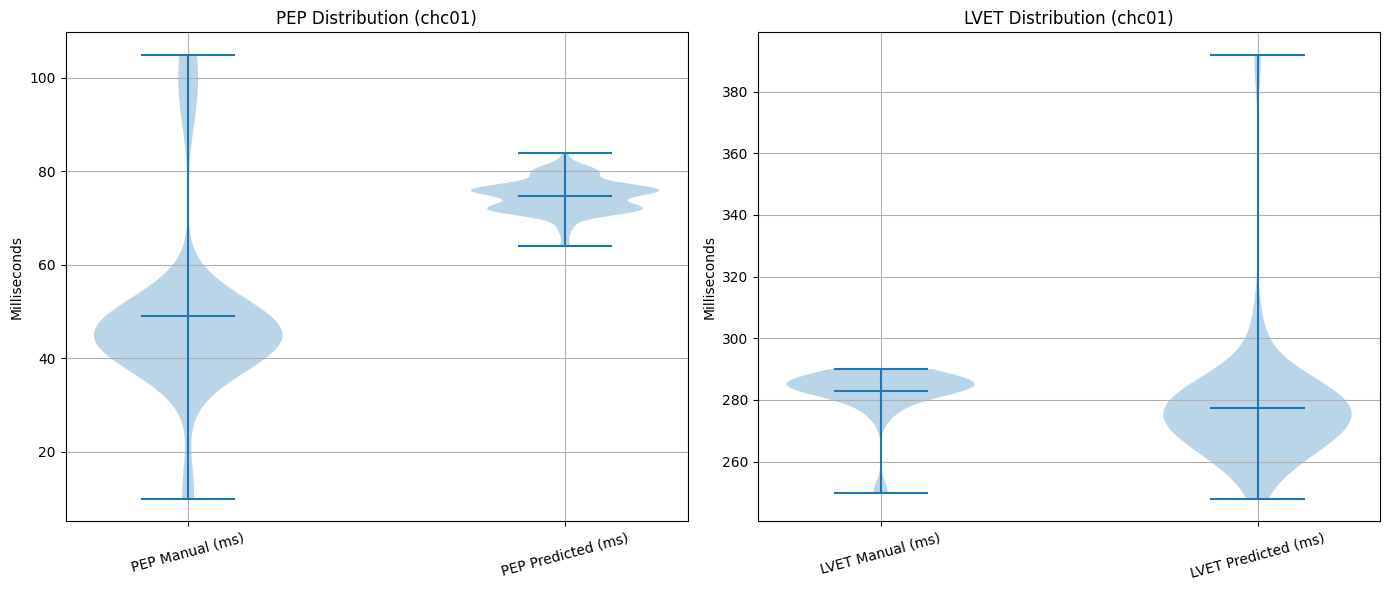

In [ ]:
import matplotlib.pyplot as plt

# Datos de PEP y LVET del conjunto chc01
pep_data = [pep_manual_all, pep_pred_all]
lvet_data = [lvet_manual_all, lvet_pred_all]

pep_labels = ['PEP Manual (ms)', 'PEP Predicted (ms)']
lvet_labels = ['LVET Manual (ms)', 'LVET Predicted (ms)']

# Configurar figura
plt.figure(figsize=(14, 6))

# PEP violin plot
plt.subplot(1, 2, 1)
plt.violinplot(pep_data, showmeans=True, showextrema=True)
plt.xticks(ticks=[1, 2], labels=pep_labels, rotation=15)
plt.ylabel("Milliseconds")
plt.title("PEP Distribution (chc01)")
plt.grid(True)

# LVET violin plot
plt.subplot(1, 2, 2)
plt.violinplot(lvet_data, showmeans=True, showextrema=True)
plt.xticks(ticks=[1, 2], labels=lvet_labels, rotation=15)
plt.ylabel("Milliseconds")
plt.title("LVET Distribution (chc01)")
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Inicializar resultados por sujeto
per_subject_results = {}

# Recorrer los archivos del subconjunto chc01
for filename in target_filenames:
    filename_key = filename + ".mat"
    if filename_key not in all_data or filename not in chc01_segment_map:
        continue

    try:
        data = all_data[filename_key]
        pep_echo = np.array(data["pep_ms"])
        lvet_echo = np.array(data["lvet_ms"])

        start_idx, end_idx = chc01_segment_map[filename]
        predicted_segments = predicted_labels_chc01[start_idx:end_idx]

        n_segments = min(len(predicted_segments), len(pep_echo), len(lvet_echo))

        pep_manual = []
        pep_pred = []
        lvet_manual = []
        lvet_pred = []

        for i in range(n_segments):
            b, x, o = predicted_segments[i]
            if not np.isnan(b):
                pep_time = ((b - offset) / fs) * 1000
                pep_pred.append(pep_time)
                pep_manual.append(pep_echo[i])
            if not np.isnan(b) and not np.isnan(x):
                lvet_time = ((x - b) / fs) * 1000
                lvet_pred.append(lvet_time)
                lvet_manual.append(lvet_echo[i])

        # Convertir a arrays
        pep_manual = np.array(pep_manual)
        pep_pred = np.array(pep_pred)
        lvet_manual = np.array(lvet_manual)
        lvet_pred = np.array(lvet_pred)

        # Alinear longitudes
        min_len_pep = min(len(pep_manual), len(pep_pred))
        min_len_lvet = min(len(lvet_manual), len(lvet_pred))

        pep_manual = pep_manual[:min_len_pep]
        pep_pred = pep_pred[:min_len_pep]
        lvet_manual = lvet_manual[:min_len_lvet]
        lvet_pred = lvet_pred[:min_len_lvet]

        # Calcular errores
        pep_mae = np.mean(np.abs(pep_pred - pep_manual)) if len(pep_manual) > 0 else np.nan
        lvet_mae = np.mean(np.abs(lvet_pred - lvet_manual)) if len(lvet_manual) > 0 else np.nan

        # Guardar resultados
        per_subject_results[filename] = {
            "pep_manual": pep_manual,
            "pep_pred": pep_pred,
            "pep_diff": pep_pred - pep_manual,
            "pep_mae": pep_mae,
            "lvet_manual": lvet_manual,
            "lvet_pred": lvet_pred,
            "lvet_diff": lvet_pred - lvet_manual,
            "lvet_mae": lvet_mae,
            "n_segments": len(pep_manual)
        }

    except Exception as e:
        print(f"Error in file {filename}: {e}")
        continue


<ipython-input-88-1ba169b08614>:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pep_maes, lvet_maes], patch_artist=True, labels=["PEP MAE", "LVET MAE"])


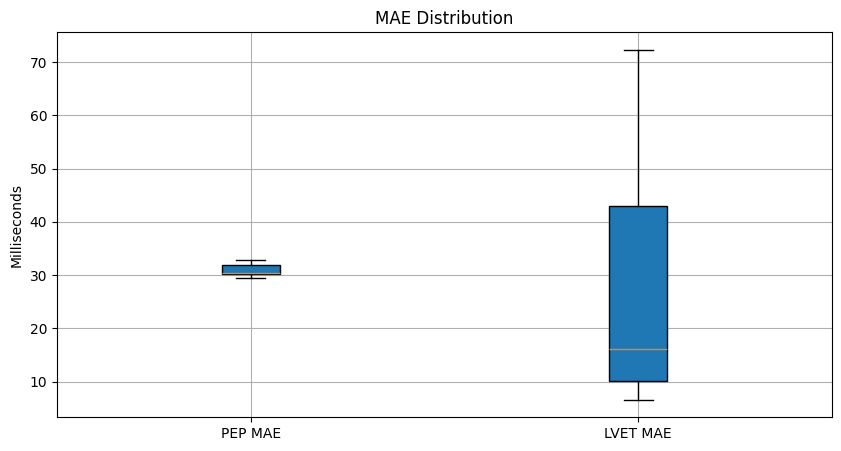

In [ ]:
pep_maes = [res["pep_mae"] for res in per_subject_results.values() if not np.isnan(res["pep_mae"])]
lvet_maes = [res["lvet_mae"] for res in per_subject_results.values() if not np.isnan(res["lvet_mae"])]

# Plot
plt.figure(figsize=(10, 5))
plt.boxplot([pep_maes, lvet_maes], patch_artist=True, labels=["PEP MAE", "LVET MAE"])
plt.title("MAE Distribution")
plt.ylabel("Milliseconds")
plt.grid(True)
plt.show()

In [ ]:
# --- PEP: % within 20ms and 40ms ---
pep_within_20 = np.nanmean(np.abs(pep_diff) <= 20) * 100
pep_within_40 = np.nanmean(np.abs(pep_diff) <= 40) * 100

# --- LVET: % within 60ms and 80ms ---
lvet_within_60 = np.nanmean(np.abs(lvet_diff) <= 60) * 100
lvet_within_80 = np.nanmean(np.abs(lvet_diff) <= 80) * 100

print(f"\n--- PEP ---")
print("Within ±20 ms: {:.2f}%".format(pep_within_20))
print("Within ±40 ms: {:.2f}%".format(pep_within_40))

print(f"\n--- LVET ---")
print("Within ±60 ms: {:.2f}%".format(lvet_within_60))
print("Within ±80 ms: {:.2f}%".format(lvet_within_80))


--- PEP ---
Within ±20 ms: 4.30%
Within ±40 ms: 94.62%

--- LVET ---
Within ±60 ms: 97.85%
Within ±80 ms: 97.85%


In [ ]:
import pandas as pd
import numpy as np

# Build a DataFrame
subject_df = pd.DataFrame([
    {
        "Subject": fname,
        "Num Segments": res["n_segments"],
        "PEP MAE (ms)": np.round(res["pep_mae"], 2),
        "LVET MAE (ms)": np.round(res["lvet_mae"], 2),
        "Mean PEP (manual)": np.round(np.mean(res["pep_manual"]), 2),
        "Mean LVET (manual)": np.round(np.mean(res["lvet_manual"]), 2)
    }
    for fname, res in per_subject_results.items()
    if not np.isnan(res["pep_mae"]) and not np.isnan(res["lvet_mae"])
])

# Display table
subject_df.sort_values("Subject").reset_index(drop=True)


,Subject,Num Segments,PEP MAE (ms),LVET MAE (ms),Mean PEP (manual),Mean LVET (manual)
0,59146238_s0000058,5,21.60,27.20,74.00,258.00
1,59146238_s0000079,3,24.00,34.33,76.67,268.33
2,59146238_s0000080,4,17.75,3.50,76.25,267.50
3,59146238_s0000081,4,26.75,39.00,76.25,267.50
4,59146238_s0000082,4,28.25,48.50,76.25,267.50
5,59146238_s0000083,4,22.75,16.00,76.25,267.50


In [ ]:
latex_table = subject_df.to_latex(
    index=False,
    longtable=True,
    caption="Per-subject Mean Absolute Error (MAE) for PEP and LVET prediction.",
    label="tab:subject_mae",
    column_format="lrrrrr",  # Adjust based on your columns
    float_format="%.2f"
)

# Save to file
with open("subject_mae_table.tex", "w") as f:
    f.write("\\chapter{Appendix}\n")
    f.write(latex_table)

# Validation with hemodynamic parameters CHC06

In [ ]:
import os
import scipy.io as sio
import numpy as np

# List of target filenames
target_filenames = [
    "59146238_s0000011",
    "59146238_s0000012",
    "59146238_s0000013",
    "59146238_s0000014",
    "59146238_s0000015",
    "59146238_s0000016",
    "59146238_s0000017",
    "59146238_s0000018",
    "59146238_s0000019",
    "59146238_s0000020"
]


# Base directory
base_dir = "/content/drive/MyDrive/TFG/Data_HeartCycle"

# Output lists
chc01_list = []
chc01_segment_map = {}  # filename → (start_idx, end_idx)
segment_index = 0

for filename in target_filenames:
    subject_id = filename.split("_")[0]
    file_path = os.path.join(base_dir, subject_id, filename + ".mat")

    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        continue

    try:
        data_hc = sio.loadmat(file_path)

        if 'measure' not in data_hc:
            print(f"No 'measure' key in {filename}")
            continue

        measures = data_hc['measure']

        # Extract signals
        icg = measures[1, 1]
        icg_time = icg['time'][0, 0].flatten()
        icg_data = icg['data'][0, 0].flatten()

        ecg = measures[0, 1]
        ecg_time = ecg['time'][0, 0].flatten()
        ecg_data = ecg['data'][0, 0].flatten()

        rpeaks = measures[2, 1]
        rpeaks_times = rpeaks['data'][0, 0].flatten()
        rpeaks_indices = np.array([np.argmin(np.abs(ecg_time - t)) for t in rpeaks_times])

        # Preprocess
        dz_dt_norm, ecg_norm = preprocess_signals(
            icg_data=icg_data,
            icg_time=icg_time,
            ecg_data=ecg_data,
            fs_icg=200,
            fs_ecg=200
        )

        # Segment and prepare input
        icg_segments = segment_icg(dz_dt_norm, rpeaks_indices, fs=200)
        ecg_segments = segment_icg(ecg_norm, rpeaks_indices, fs=200)

        icg_segments_up = upsample_segments(icg_segments, from_fs=200, to_fs=250)
        ecg_segments_up = upsample_segments(ecg_segments, from_fs=200, to_fs=250)

        X_input = prepare_icg_model_input(icg_segments_up, ecg_segments_up)

        # Track segment index range for this file
        num_segments = X_input.shape[0]
        chc01_segment_map[filename] = (segment_index, segment_index + num_segments)
        segment_index += num_segments

        chc01_list.append(X_input)

        print(f"{filename}: added {num_segments} segments")

    except Exception as e:
        print(f"Error loading {filename}: {e}")
        continue

# Final stack
chc01 = np.vstack(chc01_list) if chc01_list else np.empty((0, 200, 2))
print("Final chc01 shape:", chc01.shape)

# Split channels
icg_segments_chc01 = chc01[:, :, 0]
ecg_segments_chc01 = chc01[:, :, 1]

# Normalize per segment
X_input_chc01 = create_model_input(ecg_segments_chc01, icg_segments_chc01)

# Load trained model
predictor = load_model(model, compile=False)

# Predict
y_pred_chc01 = predictor.predict(X_input_chc01)  # shape: (n_segments, 200, 3)

# Extract predicted time indices for B, X, O
predicted_labels_chc01 = extract_predicted_points(y_pred_chc01)  # shape: (n_segments, 3)

# -----------------------------------------------------------
# Apply C-peak detection and filter invalid segments
# -----------------------------------------------------------
predicted_b_c_x_o_chc01 = detect_c_peak_after_r(icg_segments_chc01, predicted_labels_chc01, offset=offset, fs=fs)
corrected_chc01 = predicted_b_c_x_o_chc01.astype(float)

# Step 1: Remove early X points
for i in range(len(corrected_chc01)):
    x = corrected_chc01[i, 2]
    if x < offset + int(0.1 * fs):
        corrected_chc01[i, 2] = np.nan

# Step 2: Remove invalid B points
min_pep = int(0.03 * fs)
max_pep = int(0.13 * fs)
for i in range(len(corrected_chc01)):
    b, c = corrected_chc01[i, 0], corrected_chc01[i, 1]
    if np.isnan(b) or np.isnan(c) or b < offset or b >= c or not (min_pep <= b - offset <= max_pep):
        corrected_chc01[i, 0] = np.nan

# Step 3: Remove logical outliers
r_peaks_aligned = np.full(corrected_chc01.shape[0], offset)
outliers = detect_physiological_outliers(corrected_chc01, r_peaks_aligned)
valid_mask = ~(outliers['B'] | outliers['C'] | outliers['X'] | outliers['O'])
valid_indices = np.where(valid_mask)[0]
valid_index_map = {idx: i for i, idx in enumerate(valid_indices)}

# -----------------------------------------------------------
# Compute PEP and LVET only on valid segments
# -----------------------------------------------------------
pep_manual_all = []
pep_pred_all = []
lvet_manual_all = []
lvet_pred_all = []

for filename in target_filenames:
    filename_key = filename + ".mat"
    if filename_key not in all_data or filename not in chc01_segment_map:
        continue

    try:
        data = all_data[filename_key]
        pep_echo = np.array(data["pep_ms"])
        lvet_echo = np.array(data["lvet_ms"])

        start_idx, end_idx = chc01_segment_map[filename]
        file_indices = list(range(start_idx, end_idx))

        valid_in_file = [i for i, global_idx in enumerate(file_indices) if global_idx in valid_index_map]
        if not valid_in_file:
            continue

        corrected_indices = [valid_index_map[file_indices[i]] for i in valid_in_file]
        predicted_segments = corrected_chc01[valid_indices[corrected_indices]]

        pep_valid = pep_echo[valid_in_file]
        lvet_valid = lvet_echo[valid_in_file]

        pep_ms = []
        valid_pep_manual = []
        lvet_ms = []
        valid_lvet_manual = []

        for i, (b, c, x, o) in enumerate(predicted_segments):
            if not np.isnan(b):
                pep_time = ((b - offset) / fs) * 1000
                pep_ms.append(pep_time)
                valid_pep_manual.append(pep_valid[i])
            if not np.isnan(b) and not np.isnan(x):
                lvet_time = ((x - b) / fs) * 1000
                lvet_ms.append(lvet_time)
                valid_lvet_manual.append(lvet_valid[i])

        min_len_pep = min(len(valid_pep_manual), len(pep_ms))
        min_len_lvet = min(len(valid_lvet_manual), len(lvet_ms))

        pep_manual_all.extend(valid_pep_manual[:min_len_pep])
        pep_pred_all.extend(pep_ms[:min_len_pep])
        lvet_manual_all.extend(valid_lvet_manual[:min_len_lvet])
        lvet_pred_all.extend(lvet_ms[:min_len_lvet])

    except Exception as e:
        print(f"Error in file {filename}: {e}")
        continue

# Convert to arrays and round
pep_manual_all = np.array(pep_manual_all)
pep_pred_all = np.array(pep_pred_all)
lvet_manual_all = np.array(lvet_manual_all)
lvet_pred_all = np.array(lvet_pred_all)

pep_pred_all_round = np.round(pep_pred_all / 5) * 5
lvet_pred_all_round = np.round(lvet_pred_all / 5) * 5

pep_diff = pep_pred_all_round - pep_manual_all
lvet_diff = lvet_pred_all_round - lvet_manual_all

pep_mae = np.mean(np.abs(pep_diff)) if len(pep_diff) > 0 else np.nan
lvet_mae = np.mean(np.abs(lvet_diff)) if len(lvet_diff) > 0 else np.nan

# Results
print("\n--- PEP (chc01, filtered) ---")
print("PEP manual (ms):", pep_manual_all)
print("PEP predicted (ms):", pep_pred_all)
print("PEP predicted rounded (ms):", pep_pred_all_round)
print("PEP difference (ms):", pep_diff)
print(f"PEP MAE: {pep_mae:.2f} ms")

print("\n--- LVET (chc01, filtered) ---")
print("LVET manual (ms):", lvet_manual_all)
print("LVET predicted (ms):", lvet_pred_all)
print("LVET predicted rounded (ms):", lvet_pred_all_round)
print("LVET difference (ms):", lvet_diff)
print(f"LVET MAE: {lvet_mae:.2f} ms")


59146238_s0000011: added 8 segments
59146238_s0000012: added 7 segments
59146238_s0000013: added 8 segments
59146238_s0000014: added 8 segments
59146238_s0000015: added 7 segments
59146238_s0000016: added 8 segments
59146238_s0000017: added 8 segments
59146238_s0000018: added 8 segments
59146238_s0000019: added 8 segments
59146238_s0000020: added 8 segments
Final chc01 shape: (78, 200, 2)
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step

--- PEP (chc01, filtered) ---
PEP manual (ms): [75 75 75 70 70 75 70 80 75 75 70 70 75 70 75 75 75 70 70 75 70 80 75 75
 70 75 75 75 70 75 70 75 60 75 75 65 70 70 70 60 75 75 65 70 70 70 75 60
 75 75 65 70 70 70 75 60 75 75 65 70 70 70 75 60 75 75 65 70 70]
PEP predicted (ms): [ 88.  80.  84.  88.  92.  88.  76.  88.  92.  96.  92.  80.  84.  92.
 104.  84.  72. 100.  92.  80.  88.  80.  92. 104.  84.  96.  96.  88.
  92.  96.  88.  92.  80.  88.  92.  92.  96.  88.  88.  88.  88.  80.
  96.  84.  92.  96.  96.  92. 100.  88.  96.  84.  88.  92.  96.  92.
  84. 10

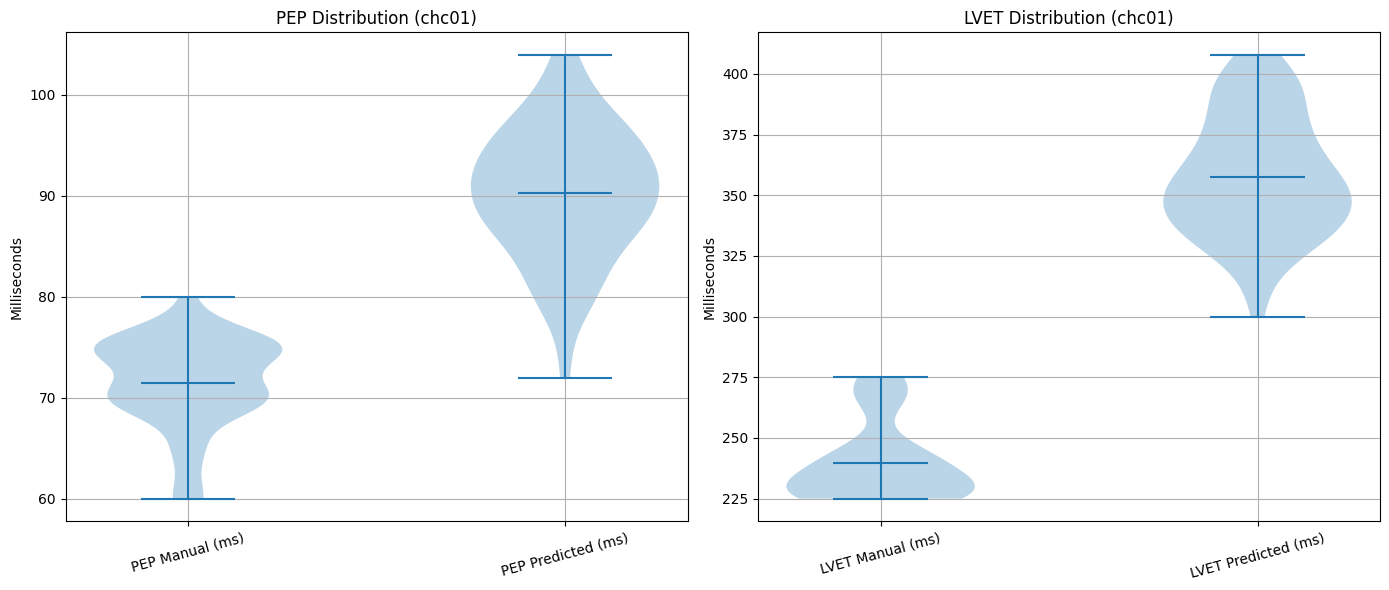

In [ ]:
import matplotlib.pyplot as plt

# Datos de PEP y LVET del conjunto chc01
pep_data = [pep_manual_all, pep_pred_all]
lvet_data = [lvet_manual_all, lvet_pred_all]

pep_labels = ['PEP Manual (ms)', 'PEP Predicted (ms)']
lvet_labels = ['LVET Manual (ms)', 'LVET Predicted (ms)']

# Configurar figura
plt.figure(figsize=(14, 6))

# PEP violin plot
plt.subplot(1, 2, 1)
plt.violinplot(pep_data, showmeans=True, showextrema=True)
plt.xticks(ticks=[1, 2], labels=pep_labels, rotation=15)
plt.ylabel("Milliseconds")
plt.title("PEP Distribution (chc01)")
plt.grid(True)

# LVET violin plot
plt.subplot(1, 2, 2)
plt.violinplot(lvet_data, showmeans=True, showextrema=True)
plt.xticks(ticks=[1, 2], labels=lvet_labels, rotation=15)
plt.ylabel("Milliseconds")
plt.title("LVET Distribution (chc01)")
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Inicializar resultados por sujeto
per_subject_results = {}

# Recorrer los archivos del subconjunto chc01
for filename in target_filenames:
    filename_key = filename + ".mat"
    if filename_key not in all_data or filename not in chc01_segment_map:
        continue

    try:
        data = all_data[filename_key]
        pep_echo = np.array(data["pep_ms"])
        lvet_echo = np.array(data["lvet_ms"])

        start_idx, end_idx = chc01_segment_map[filename]
        predicted_segments = predicted_labels_chc01[start_idx:end_idx]

        n_segments = min(len(predicted_segments), len(pep_echo), len(lvet_echo))

        pep_manual = []
        pep_pred = []
        lvet_manual = []
        lvet_pred = []

        for i in range(n_segments):
            b, x, o = predicted_segments[i]
            if not np.isnan(b):
                pep_time = ((b - offset) / fs) * 1000
                pep_pred.append(pep_time)
                pep_manual.append(pep_echo[i])
            if not np.isnan(b) and not np.isnan(x):
                lvet_time = ((x - b) / fs) * 1000
                lvet_pred.append(lvet_time)
                lvet_manual.append(lvet_echo[i])

        # Convertir a arrays
        pep_manual = np.array(pep_manual)
        pep_pred = np.array(pep_pred)
        lvet_manual = np.array(lvet_manual)
        lvet_pred = np.array(lvet_pred)

        # Alinear longitudes
        min_len_pep = min(len(pep_manual), len(pep_pred))
        min_len_lvet = min(len(lvet_manual), len(lvet_pred))

        pep_manual = pep_manual[:min_len_pep]
        pep_pred = pep_pred[:min_len_pep]
        lvet_manual = lvet_manual[:min_len_lvet]
        lvet_pred = lvet_pred[:min_len_lvet]

        # Calcular errores
        pep_mae = np.mean(np.abs(pep_pred - pep_manual)) if len(pep_manual) > 0 else np.nan
        lvet_mae = np.mean(np.abs(lvet_pred - lvet_manual)) if len(lvet_manual) > 0 else np.nan

        # Guardar resultados
        per_subject_results[filename] = {
            "pep_manual": pep_manual,
            "pep_pred": pep_pred,
            "pep_diff": pep_pred - pep_manual,
            "pep_mae": pep_mae,
            "lvet_manual": lvet_manual,
            "lvet_pred": lvet_pred,
            "lvet_diff": lvet_pred - lvet_manual,
            "lvet_mae": lvet_mae,
            "n_segments": len(pep_manual)
        }

    except Exception as e:
        print(f"Error in file {filename}: {e}")
        continue


<ipython-input-93-1ba169b08614>:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pep_maes, lvet_maes], patch_artist=True, labels=["PEP MAE", "LVET MAE"])


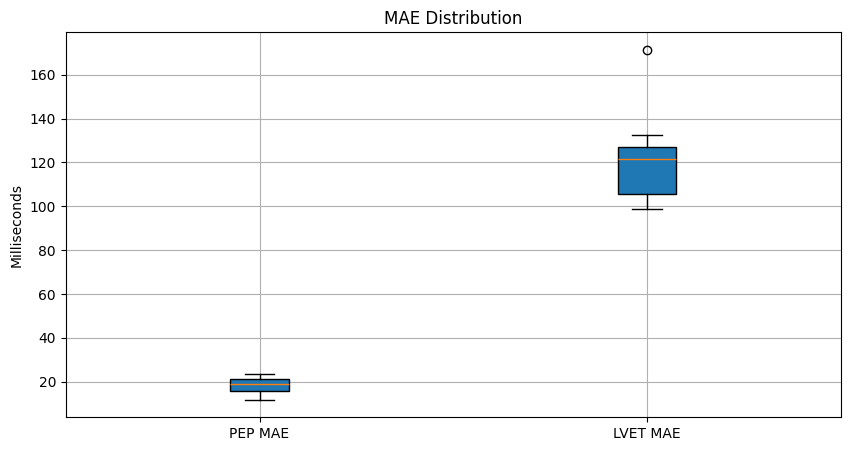

In [ ]:
pep_maes = [res["pep_mae"] for res in per_subject_results.values() if not np.isnan(res["pep_mae"])]
lvet_maes = [res["lvet_mae"] for res in per_subject_results.values() if not np.isnan(res["lvet_mae"])]

# Plot
plt.figure(figsize=(10, 5))
plt.boxplot([pep_maes, lvet_maes], patch_artist=True, labels=["PEP MAE", "LVET MAE"])
plt.title("MAE Distribution")
plt.ylabel("Milliseconds")
plt.grid(True)
plt.show()

In [ ]:
# --- PEP: % within 20ms and 40ms ---
pep_within_20 = np.nanmean(np.abs(pep_diff) <= 20) * 100
pep_within_40 = np.nanmean(np.abs(pep_diff) <= 40) * 100

# --- LVET: % within 60ms and 80ms ---
lvet_within_60 = np.nanmean(np.abs(lvet_diff) <= 60) * 100
lvet_within_80 = np.nanmean(np.abs(lvet_diff) <= 80) * 100

print(f"\n--- PEP ---")
print("Within ±20 ms: {:.2f}%".format(pep_within_20))
print("Within ±40 ms: {:.2f}%".format(pep_within_40))

print(f"\n--- LVET ---")
print("Within ±60 ms: {:.2f}%".format(lvet_within_60))
print("Within ±80 ms: {:.2f}%".format(lvet_within_80))


--- PEP ---
Within ±20 ms: 72.46%
Within ±40 ms: 100.00%

--- LVET ---
Within ±60 ms: 2.94%
Within ±80 ms: 13.24%


In [ ]:
import pandas as pd
import numpy as np

# Build a DataFrame
subject_df = pd.DataFrame([
    {
        "Subject": fname,
        "Num Segments": res["n_segments"],
        "PEP MAE (ms)": np.round(res["pep_mae"], 2),
        "LVET MAE (ms)": np.round(res["lvet_mae"], 2),
        "Mean PEP (manual)": np.round(np.mean(res["pep_manual"]), 2),
        "Mean LVET (manual)": np.round(np.mean(res["lvet_manual"]), 2)
    }
    for fname, res in per_subject_results.items()
    if not np.isnan(res["pep_mae"]) and not np.isnan(res["lvet_mae"])
])

# Display table
subject_df.sort_values("Subject").reset_index(drop=True)


,Subject,Num Segments,PEP MAE (ms),LVET MAE (ms),Mean PEP (manual),Mean LVET (manual)
0,59146238_s0000058,5,21.60,27.20,74.00,258.00
1,59146238_s0000079,3,24.00,34.33,76.67,268.33
2,59146238_s0000080,4,17.75,3.50,76.25,267.50
3,59146238_s0000081,4,26.75,39.00,76.25,267.50
4,59146238_s0000082,4,28.25,48.50,76.25,267.50
5,59146238_s0000083,4,22.75,16.00,76.25,267.50


In [ ]:
latex_table = subject_df.to_latex(
    index=False,
    longtable=True,
    caption="Per-subject Mean Absolute Error (MAE) for PEP and LVET prediction.",
    label="tab:subject_mae",
    column_format="lrrrrr",  # Adjust based on your columns
    float_format="%.2f"
)

# Save to file
with open("subject_mae_table.tex", "w") as f:
    f.write("\\chapter{Appendix}\n")
    f.write(latex_table)